# Setup

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import logging
import os
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

pd.options.mode.copy_on_write = True

from foraging.utils import INDEX, MIN_INDEX
from foraging.utils.data import make_df, display_df, filter_df, get_blocks, get_continuous_from_df_to_dict, \
    exclusion_criteria
from foraging.plotting import bp, titler, enhanced_violinplot, PALETTE, PALETTE_DARK
from foraging.plotting.behavior import plot_pushes, plot_block_events, plot_experiment_parameters, plot_experiment_overview, \
    plot_continuous3d_dict, plot_continuous3d_df, plot_continuous2d_df

# Filter out annoying matplotlib logs
mlogger = logging.getLogger('matplotlib')
mlogger.setLevel(logging.WARNING)

EXPERIMENT_DIR = '../data/experiments'
ANALYSIS_DIR = '../data/analysis'
FIGURES_DIR = '../figures'
SEED = 42

# Load Data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is as follows:

+--- subject  
&nbsp;&nbsp;&nbsp;&nbsp; |___ session  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ block (kappa, stimulus type, schedules)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ push times  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ reward outcomes  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ push times

For human data, each session is a subject. Otherwise noted, subjects underwent multiple sessions, one session per day, and each contain multiple blocks with different experiment parameters per block.
Refer to the docs for more details.

Below is a DataFrame showing a subset of the data. Refer to the docstring of `make_df` for more information about the contents of the DataFrame.

In [2]:
df = make_df(EXPERIMENT_DIR)
display_df(df, ["box", "push times", "reward outcomes"])

|                                                       | box   |   push times | reward outcomes   |
|:------------------------------------------------------|:------|-------------:|:------------------|
| ('dylan', 20211206, 1, 1, 'probability', 1, 1.0, 'M') | fast  |       26.75  | True              |
| ('dylan', 20211206, 1, 2, 'probability', 1, 1.0, 'M') | fast  |       31.159 | True              |
| ('dylan', 20211206, 1, 3, 'probability', 1, 1.0, 'M') | fast  |       33.338 | True              |
| ('dylan', 20211206, 1, 4, 'probability', 1, 1.0, 'M') | fast  |       35.537 | False             |
| ('dylan', 20211206, 1, 5, 'probability', 1, 1.0, 'M') | fast  |       37.476 | False             |

## Data Overview
A quick overview of the summary statistics

In [3]:
print("schedules experienced by each subject")
print(df.groupby('subject')['schedule'].unique())

schedules experienced by each subject
subject
dylan                                  [15.0, 35.0, 21.0]
humans                                  [14.0, 21.0, 7.0]
marco                            [35.0, 15.0, 21.0, 30.0]
viktor    [15.0, 21.0, 35.0, 28.0, 7.0, 14.0, 20.0, 80.0]
Name: schedule, dtype: object


<Axes: xlabel='duration', ylabel='Count'>

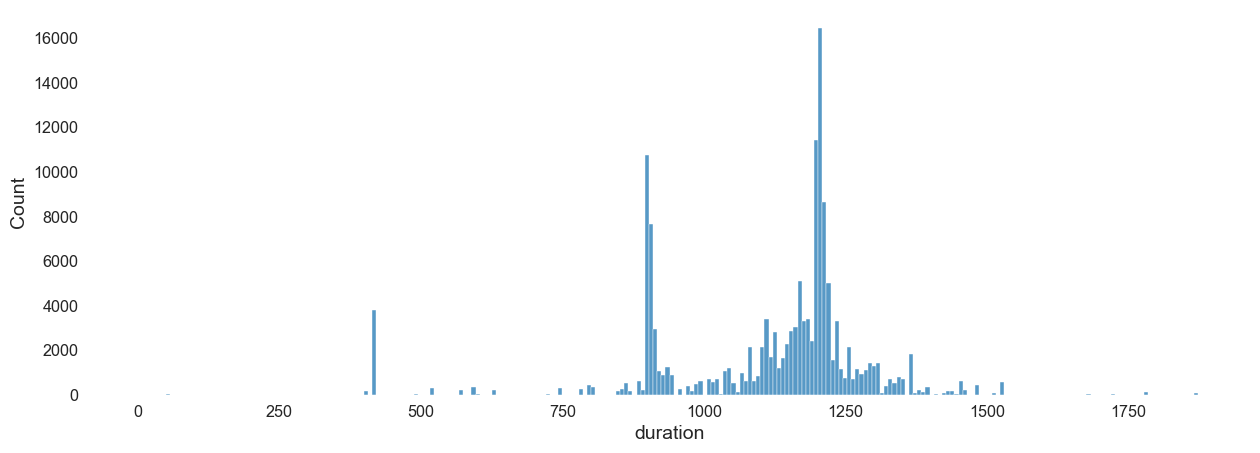

In [46]:
sns.histplot(df, x = 'duration')

<Axes: xlabel='subject', ylabel='n pushes per block'>

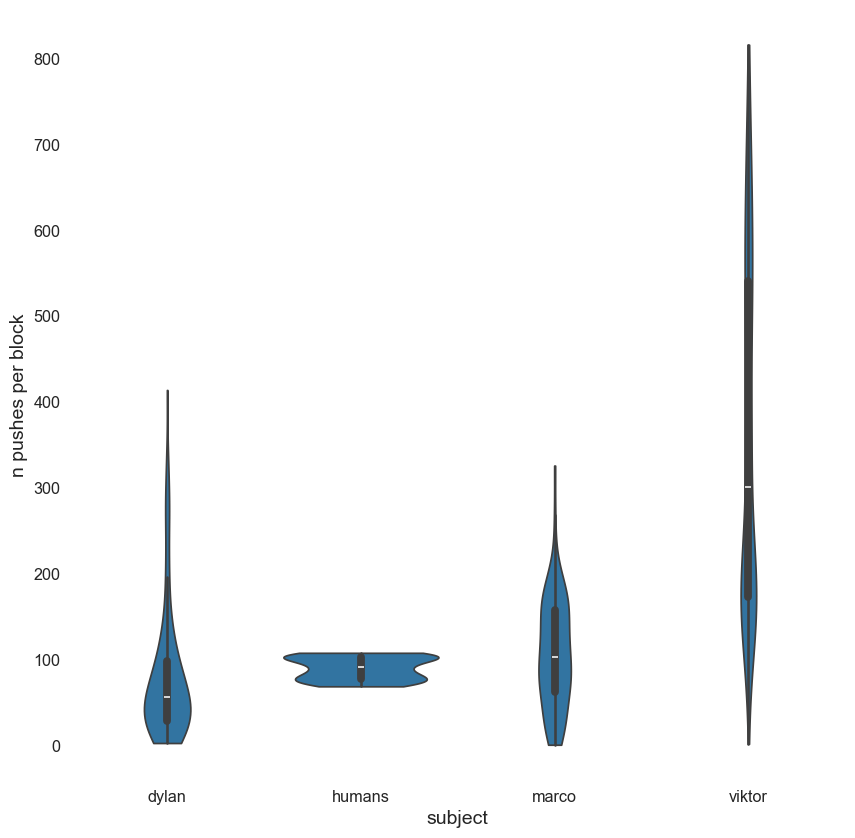

In [4]:
top_n = df.groupby(['subject', 'session', 'block']).size().reset_index(name='n pushes per block')
fig, ax = plt.subplots(figsize=(10, 10))
sns.violinplot(top_n, x='subject', y='n pushes per block', cut=0, ax=ax)

Here is a bird's eye view of one subject's behavioral data over the course of the entire experiment. Each row is a session of consecutive blocks. Each block's pushes are displayed as a raster plot over the duration of that block, and the pushes at each box position are stacked on top of each other (top to bottom is 3, 2, 1). Finally, pushes are colored by box quality, so we can see how the schedules are assigned to each box over consecutive blocks.

<Axes: title={'center': 'Overview of pushes over entire experiment\nsubject = viktor'}, xlabel='time in block (s)', ylabel='session'>

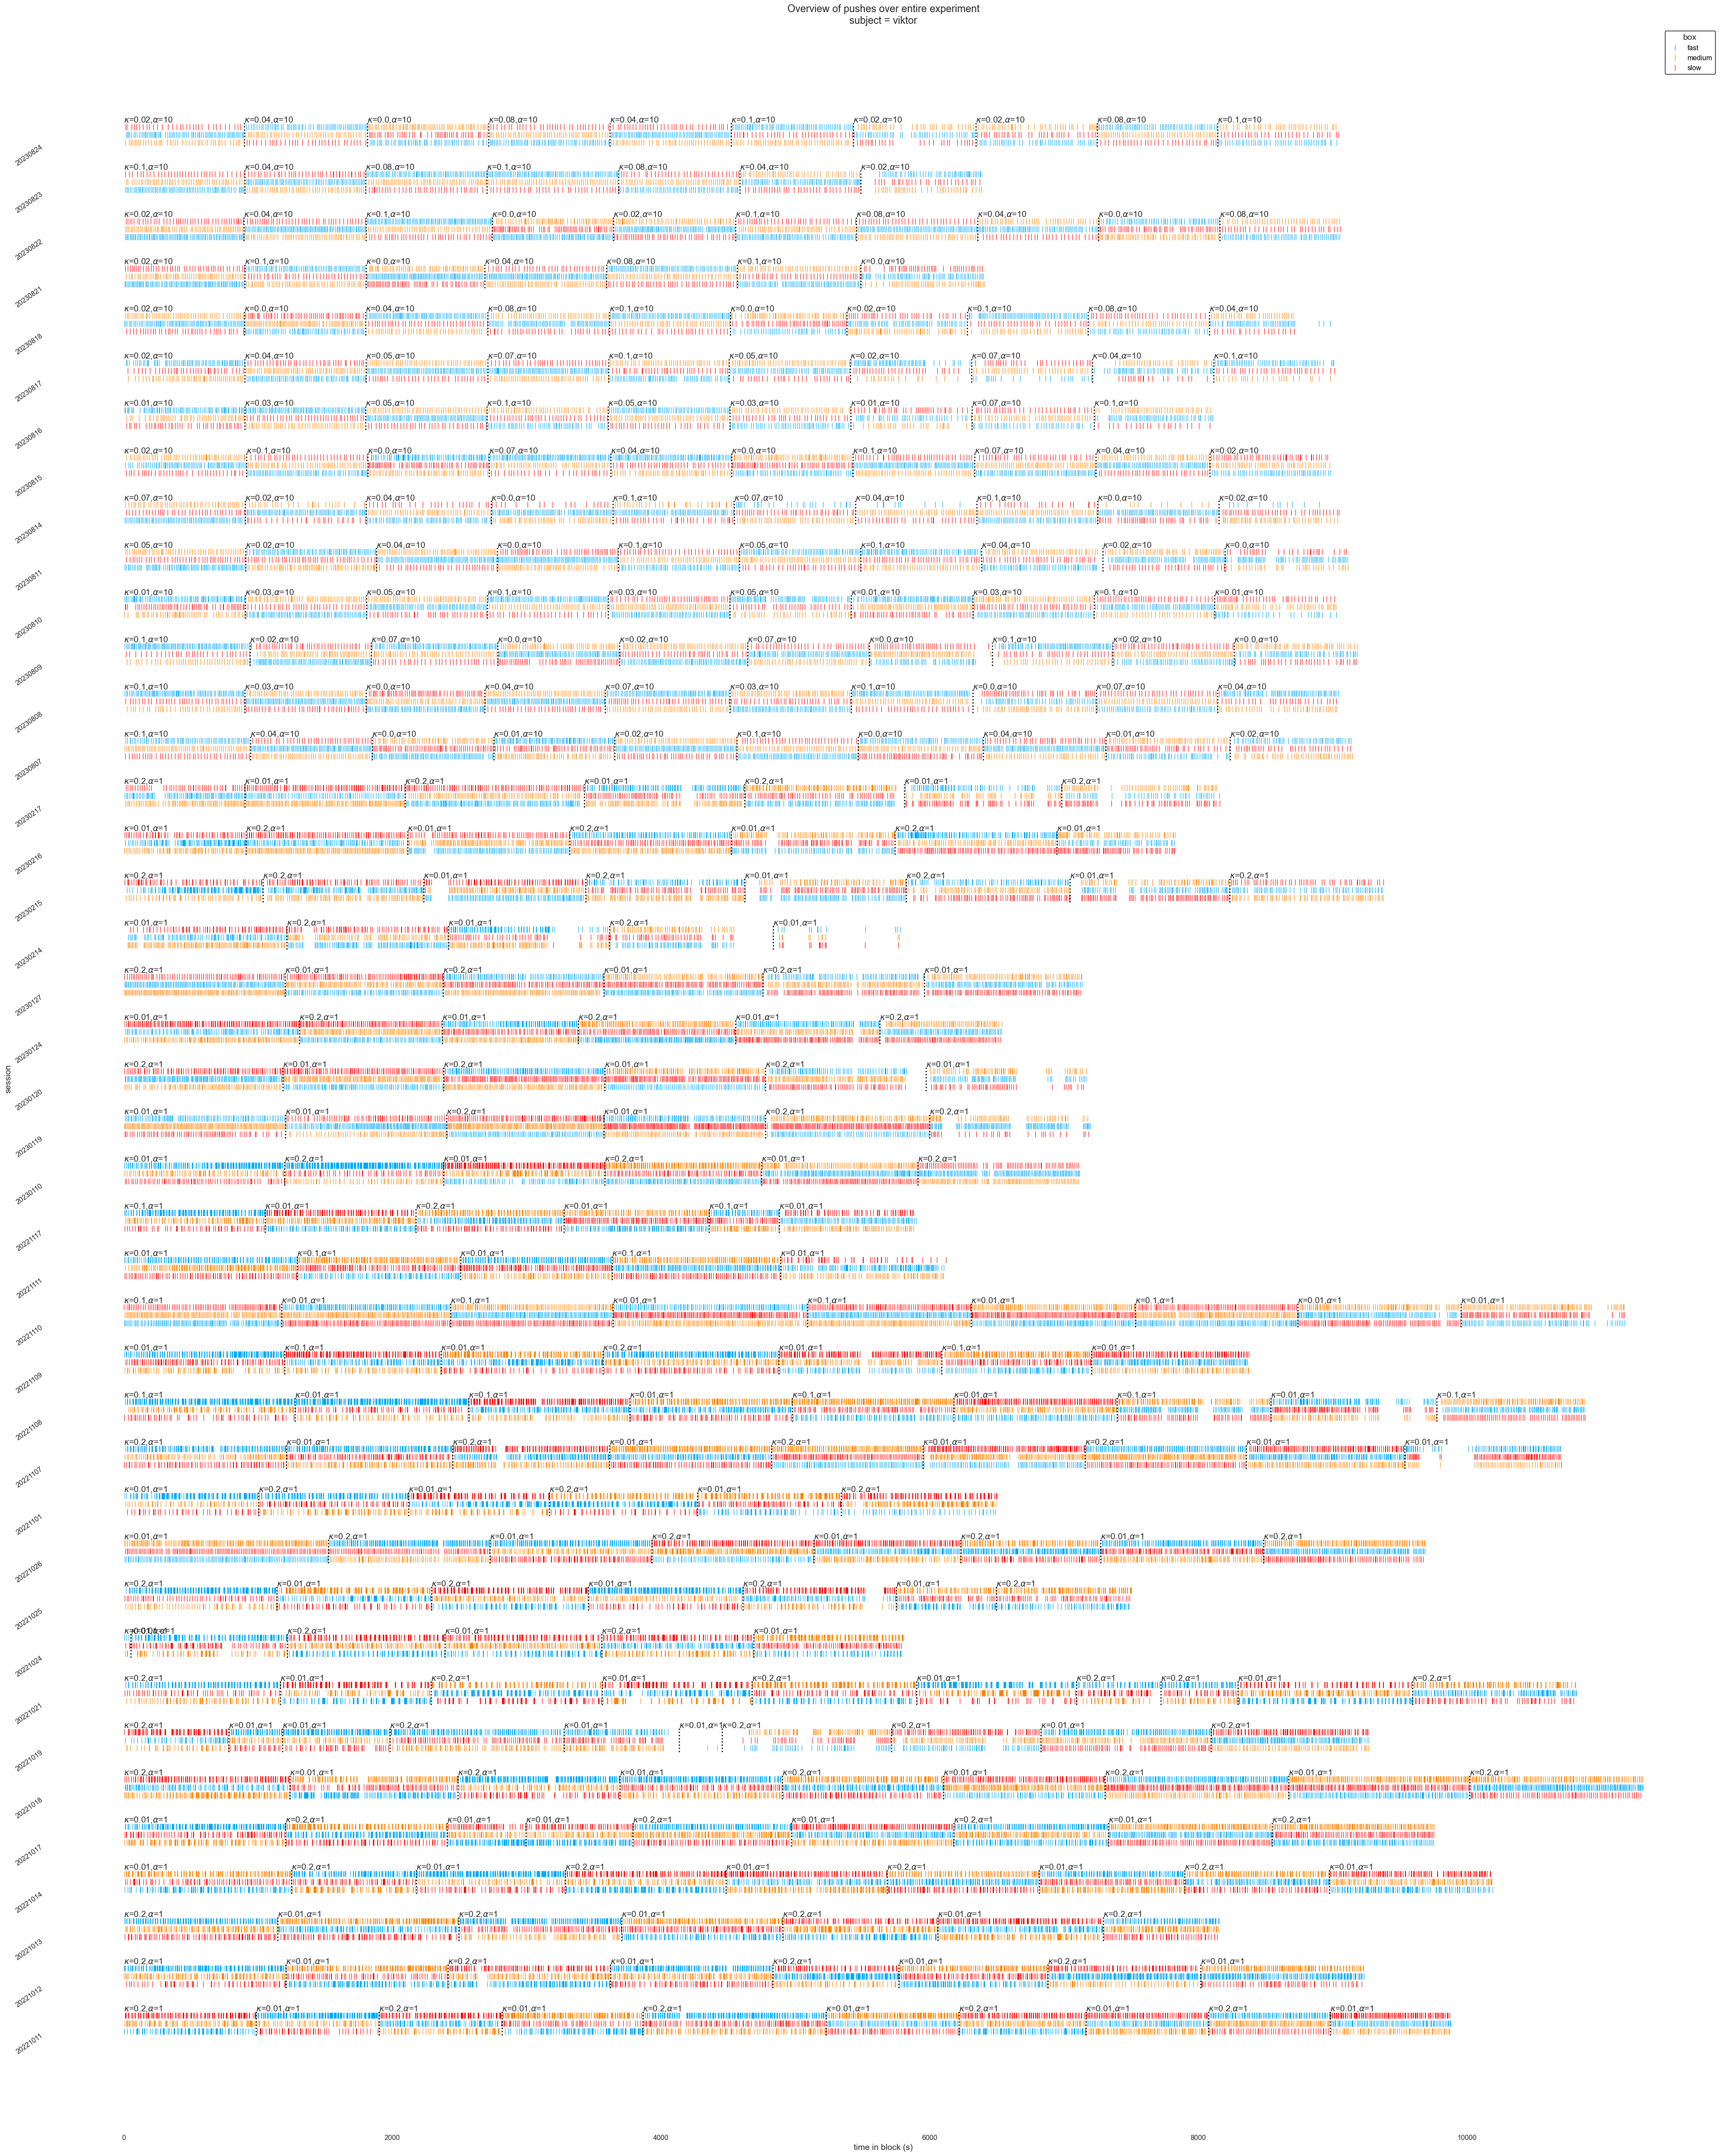

In [60]:
conds = dict(subject='viktor')
plot_experiment_overview(df, conds=conds, title_prefix='Overview of pushes over entire experiment', annotate_block=True,
                         fig_kwargs=dict(figsize=(40, 50)))

# Analyze Outliers

Before we get to the fun stuff of analyzing behavior, it is worth taking pains to clean the data by filtering out behavior that seems "off-task". This may seem counterproductive to the goal of analyzing free behavior, but there is a trade-off between the goals of modeling as much of the behavior as possible and having a simple model of a subset of "interesting" behavior. The goal of this notebook is to design a rudimentary exclusion criteria to isolate this subset of outliers. Intuitively, long bouts of time when the subject is not pushing should be indicative of off-task or "lapse" behavior. This is a vague criterion that we will refine by exploring the distribution of consecutive push intervals, the times between consecutive pushes. Some of these push intervals will occur back-to-back at the same box, which we will refer to as the "stay pushes". Push intervals that start at one box and end at a different box will be referred to as "switch times". These include the transit time, which should be equal between all boxes as they are equidistant from each other, and any time spent between boxes. Lastly, there are also push intervals that start and end at the same box, including any pushes taken at other boxes, called "same-box push intervals". These are hypothesized to be proportional to the mean schedules of the respective box if the subject successfully "matches" the resources (time in our case) they allocate to a box with the reward rate achieved at that box. The matching law is one normative theory of foraging whose predictions we can compare our subject's data against, and after filtering the data, we will explore these predictions.

<Axes: title={'center': 'Distribution of consecutive push intervals\n'}, xlabel='subject', ylabel='consecutive push intervals (s)'>

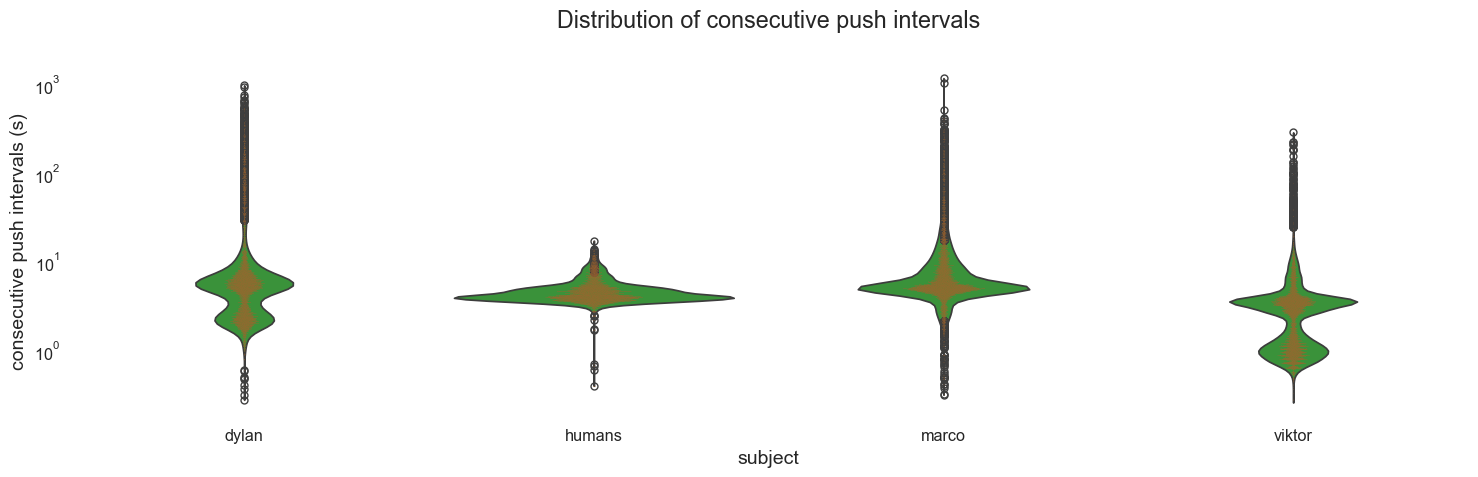

In [32]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
bp(sns.boxplot)(df, x='subject', y='consecutive push intervals', showcaps=False,
                showbox=False, log_scale=True, whiskerprops={'visible': False}, medianprops={'visible': False},
                legend=False, ax=ax)
bp(sns.swarmplot)(df.groupby('subject').sample(10000, random_state=SEED, replace=True), x='subject',
                  y='consecutive push intervals', legend=False, log_scale=True, size=0.25, dodge=True, ax=ax)
bp(sns.violinplot)(df, x='subject', y='consecutive push intervals', cut=0,
                   inner=None, log_scale=True, common_norm=True,
                   title_prefix="Distribution of consecutive push intervals",
                   y_unit='s', legend=False, ax=ax)

Each subject's push intervals are shown on a logscale. The individual circles are outliers that would show up on a boxplot of the data, defined as all datapoints lying outside of 1.5*IQR (inter-quartile range) from the first and third quartile (in the original data space, not log). We see a mix of bimodality and unimodality among the subjects. Next, we will sort each push interval by the percentile at which it occurs in each subject's data and identify the 90th percentile.

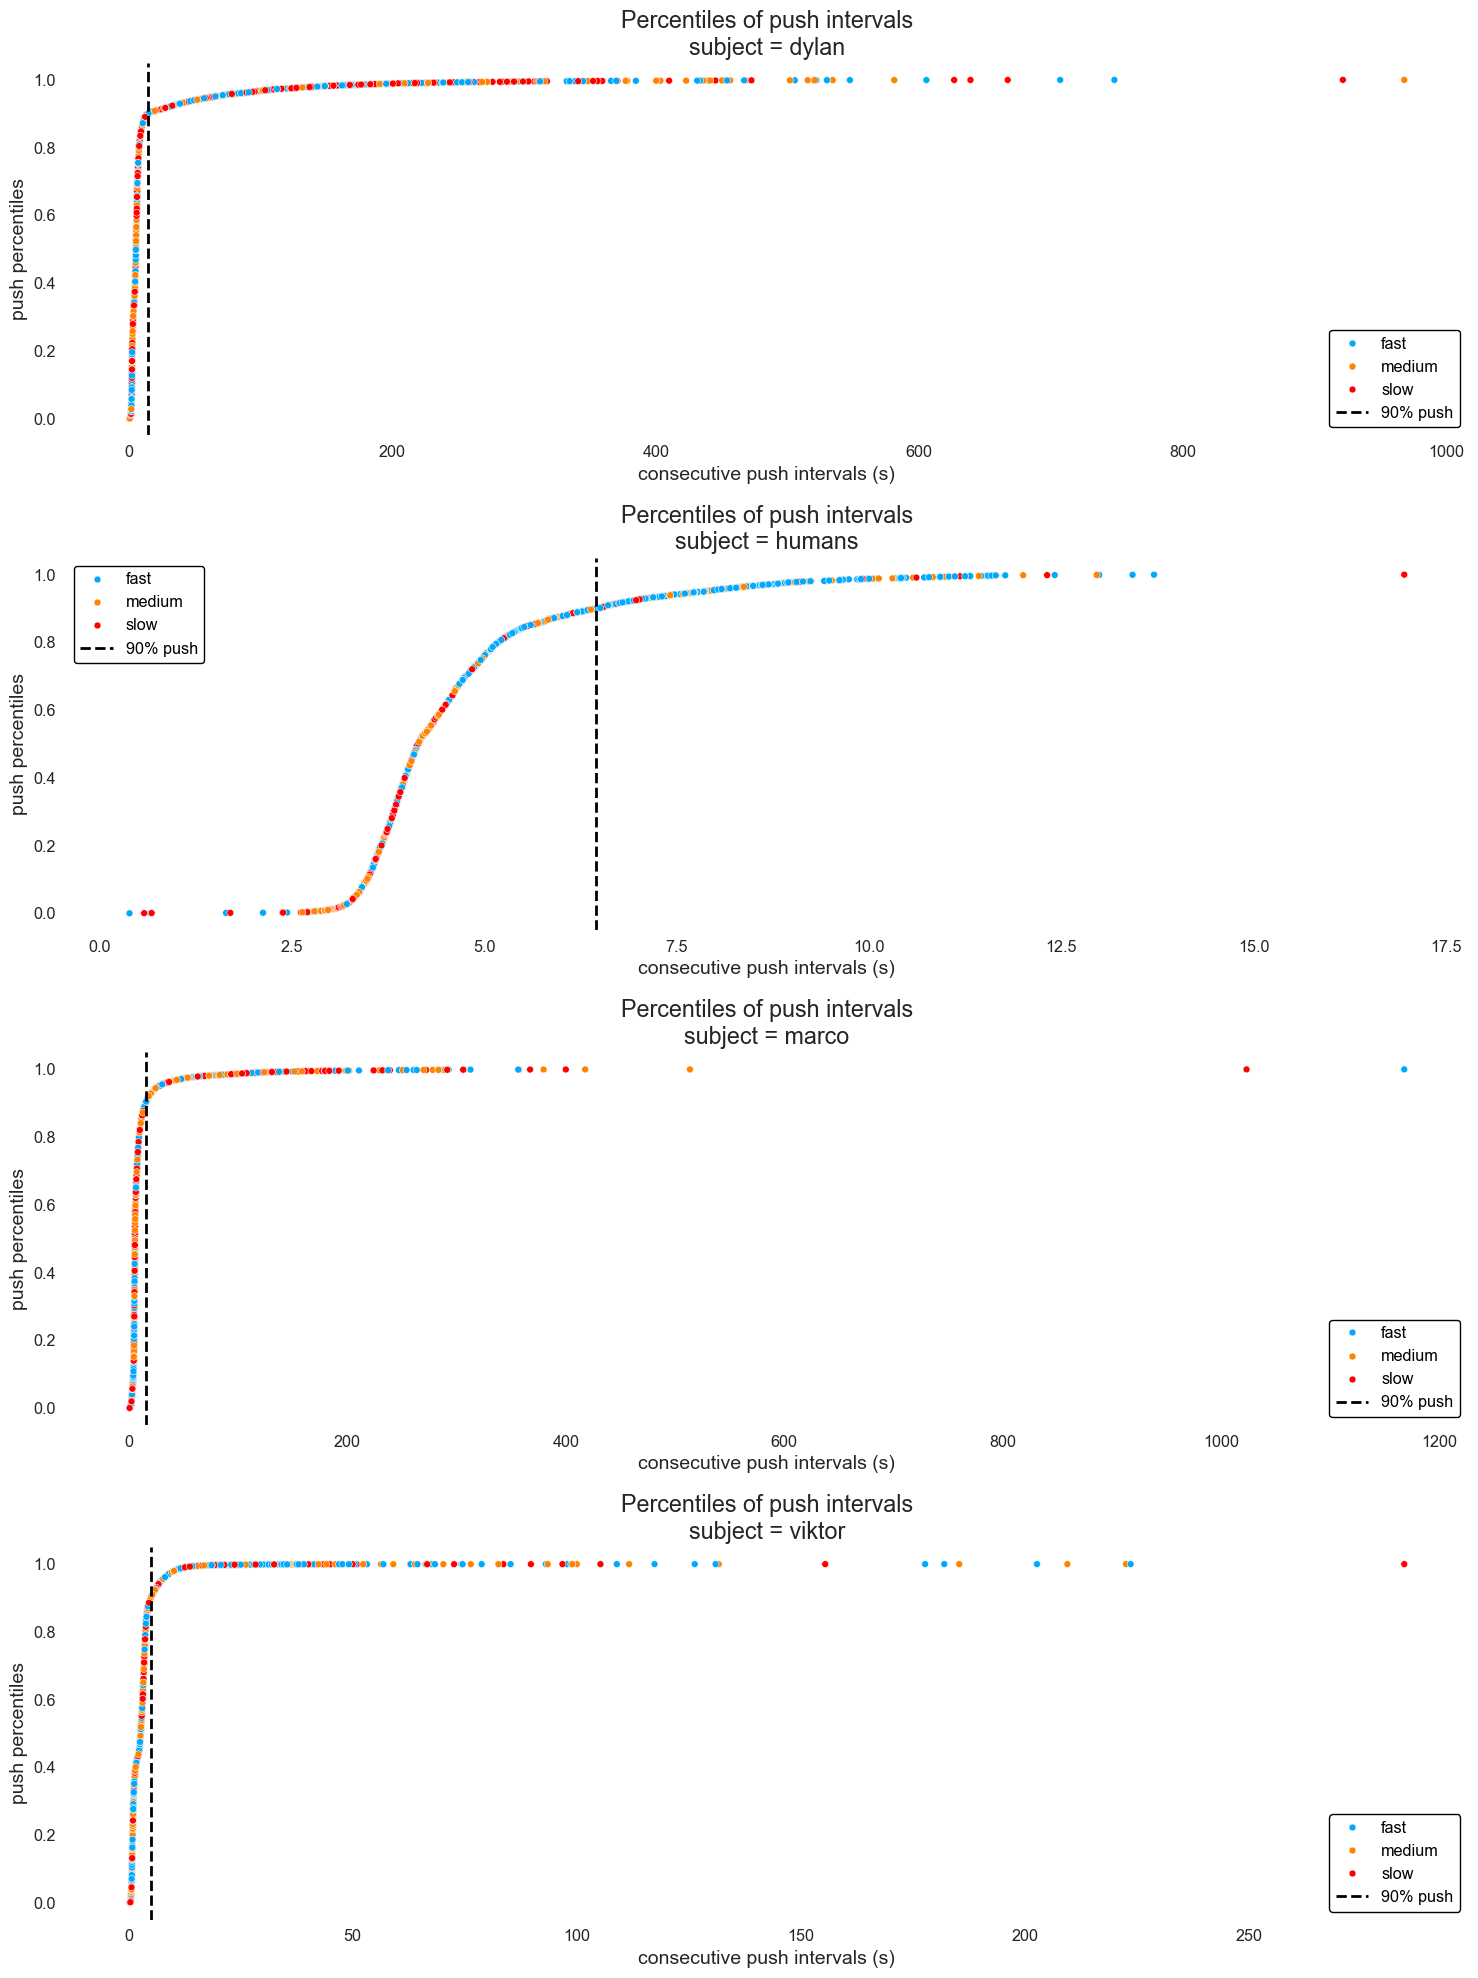

In [3]:
# Sort pushes by percentiles
df['push percentiles'] = df.groupby('subject', as_index=False)['consecutive push intervals'].rank(pct=True)
subjects = df.index.unique('subject')
percentile = 0.9
fig, axes = plt.subplots(len(subjects), 1, figsize=(15, 20))
for i, subj in enumerate(subjects):
    bp(sns.scatterplot)(df, x='consecutive push intervals', y='push percentiles', hue='box', palette=PALETTE,
                        conds={'subject': subj}, title_prefix="Percentiles of push intervals", x_unit='s', ax=axes[i])
    y = df.loc[(subj,), 'push percentiles'].sort_values()
    x = df.loc[(subj,), 'consecutive push intervals'].sort_values()
    perc_idx = np.argmin((y - percentile) ** 2)
    axes[i].axvline(x.iloc[perc_idx], color='black', linestyle='dashed', label=f'{int(percentile * 100):d}% push')
    axes[i].legend()
fig.tight_layout()

The 90th percentile emerges at different points for each subject A good threshold that doesn't exclude potentially interesting behavior should be less conservative than these knees. To get a better sense of an appropriate boundary, we will consider example blocks containing the longest push intervals.

## Example Blocks


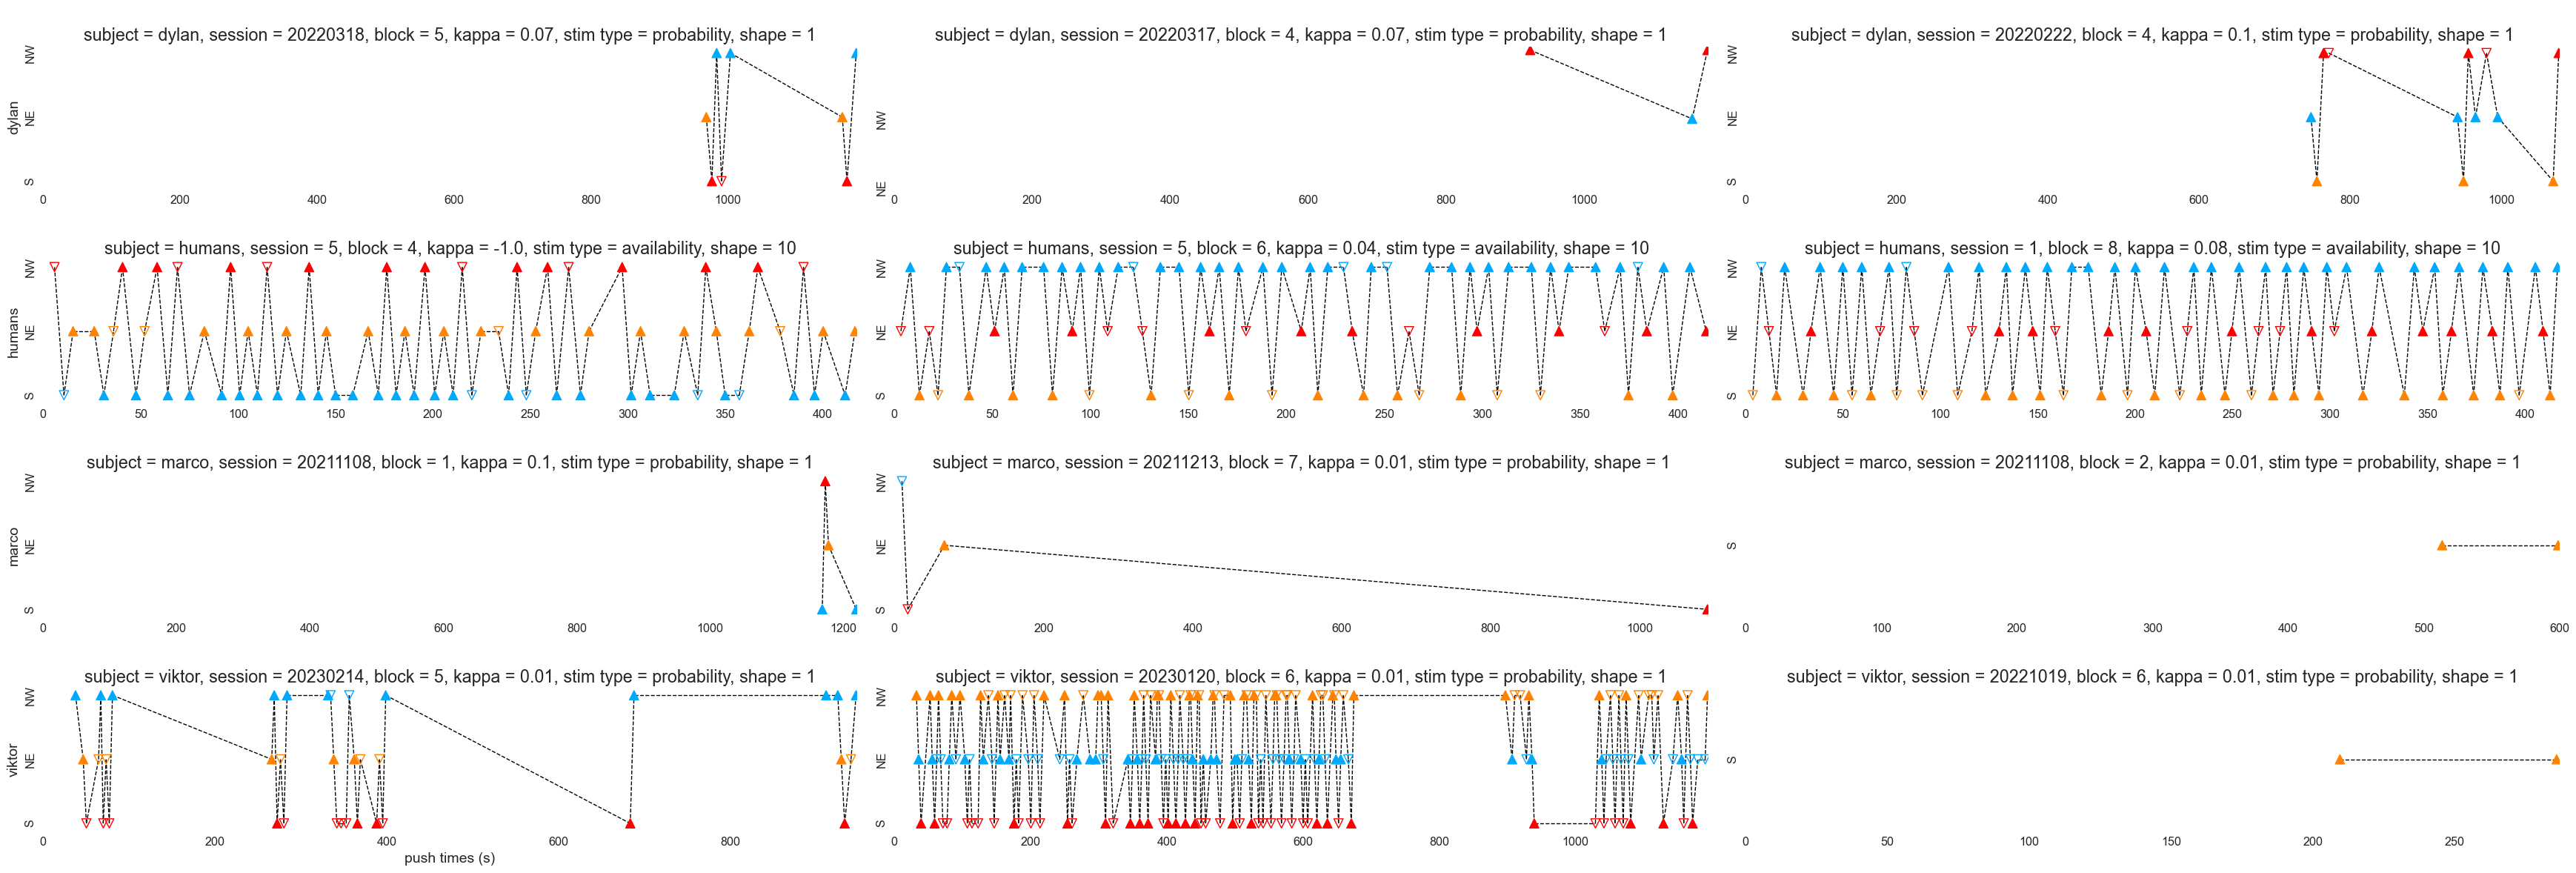

In [4]:
# Sort push intervals in descending order (longest push intervals at the top)
df_sorted = df.sort_values(by='consecutive push intervals', ascending=False)

# Plot blocks containing the top_n push intervals
top_n = 3
fig, axes = plt.subplots(len(subjects), top_n, figsize=(35, 12))
for i, subject in enumerate(subjects):
    df_subject = filter_df(df_sorted, {'subject': subject}, attempt_index=False)
    for j, (idx, g) in enumerate(get_blocks(df_subject, sort=False)):
        if j >= top_n:
            break
        conds = dict(zip(INDEX[:MIN_INDEX - 1], idx))
        plot_pushes(g.sort_index(), conds=conds, title_prefix='', legend=False, ax=axes[i, j])
        if not i * top_n + j == (len(subjects) - 1) * top_n:
            axes[i, j].set_xlabel("")
            axes[i, j].set_ylabel("")
        if j == 0:
            axes[i, j].set_ylabel(subject)
fig.tight_layout()

Here are the blocks that contain the top push intervals for each subject. Each push is labeled by its reward outcome, with filled symbols indicating reward and empty no reward, and is colored by the schedule of the box they occur at. Dashed lines connect consecutive pushes. Some push intervals appear long because the subject doesn't initiate the task for a long time. Also, some blocks are very sparse while other blocks have long segments of task-engaged behavior interrupted by long breaks when the monkey does not push. One consideration for the exclusion criteria is to drop blocks that contain fewer than n pushes e.g. 10 pushes, even if there are a couple "reasonable looking" pushes; it's very likely the animal is actually disengaged the entirety of that block, thus casting doubt on any reasonable behavior appearing in that block. For blocks that are denser in pushes, we need a different criteria. Next, we'll consider possible correlates of long push intervals, such as reward and spatial position.

## Reward

Now we will compare the relationship between reward and lapses for the top 10% of push intervals and a control group of "normal" pushes sampled from the middle 50%. First, for each push, we will consider the fraction of rewarded pushes in the last 30 seconds preceding the *previous* push, because we are interested in seeing whether satiety can predict that the next push will be longer than usual. If the fraction of rewarded pushes is particularly high in the top 10% compared to the control, then it's possible that the subject is satiated and thus more likely disengage from the task for some time. We will also consider the effect of disappointing outcomes on the likelihood of lapsing-- if, among the unrewarded outcomes prior to the top 10% pushes, the previous push interval is longer compared to the control, then this could be indicative of disappointment playing a role in triggering lapses.

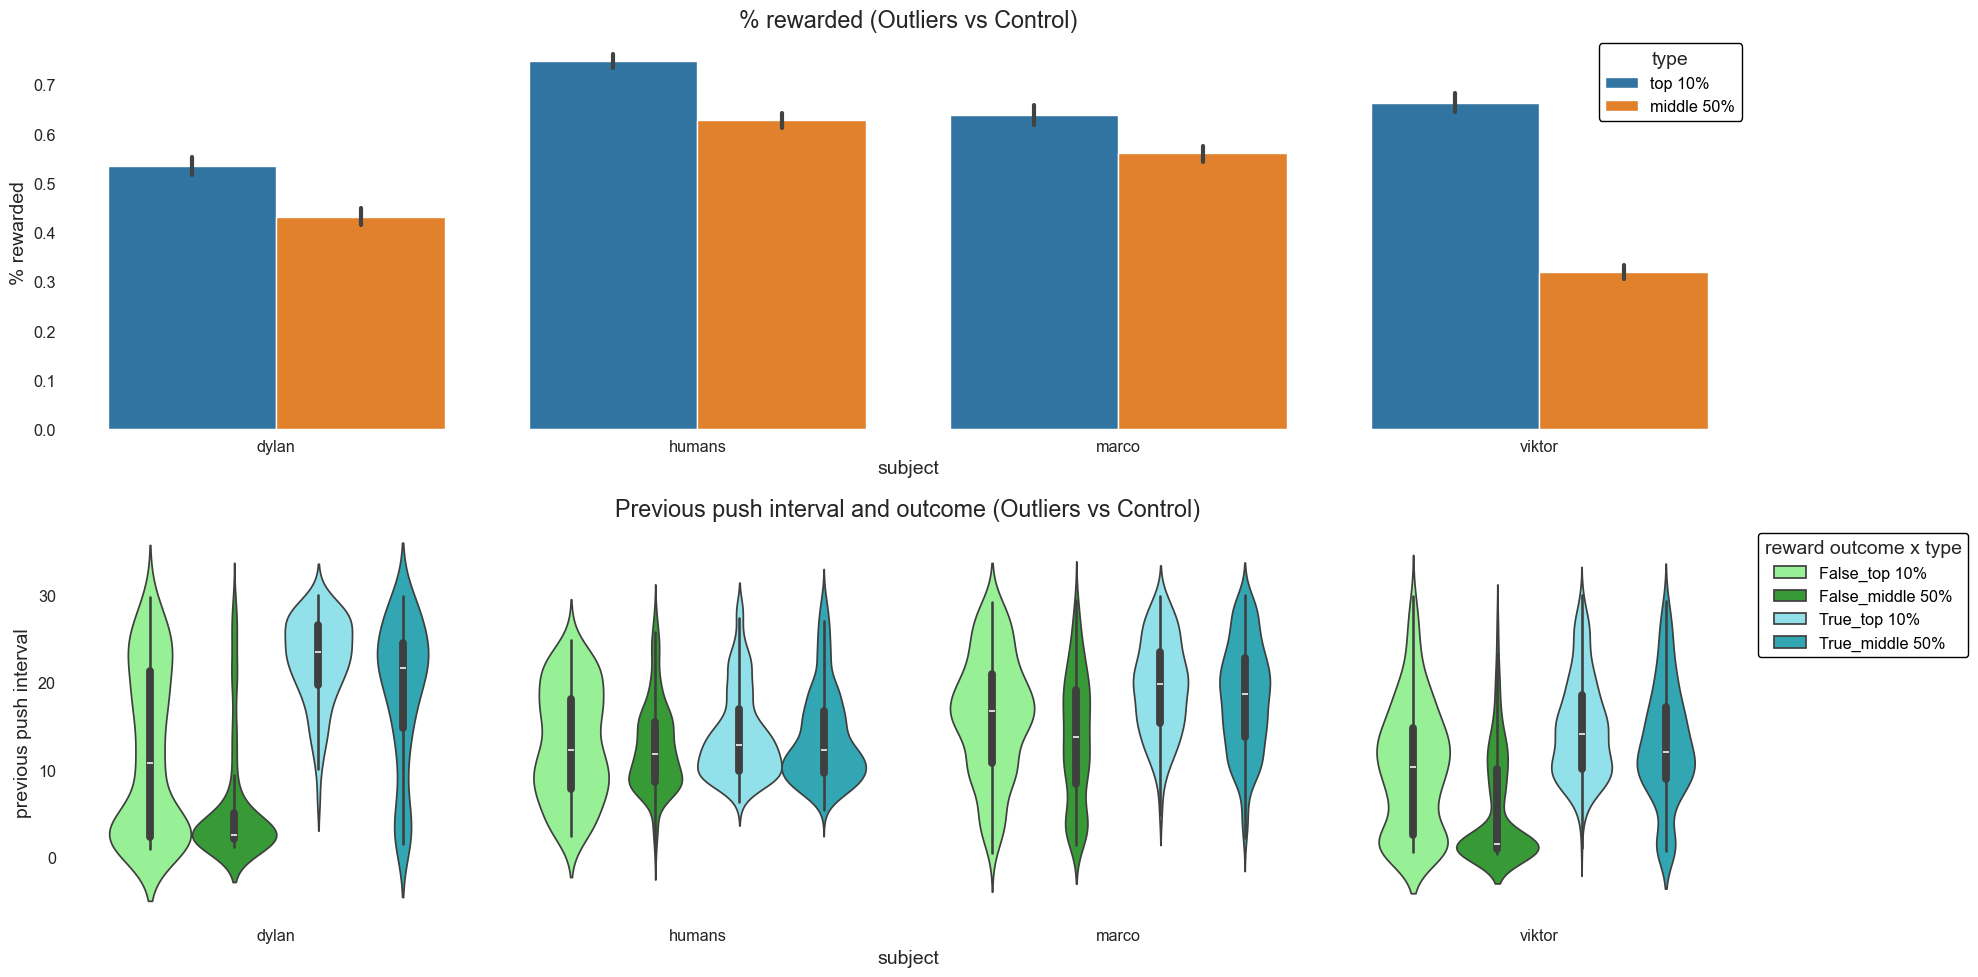

In [12]:
n_samples = 1000  # Sample n pushes
window = 30  # Time-window preceding pushes to calculate the reward rate, in seconds
percentile = 0.9
df_rate_content = {'subject': [], 'push intervals': [], '% rewarded': [], 'previous push interval': [], 'previous reward outcome': [], 'type': []}
outlier_label = f"top {round((1-percentile)*100)}%"
control_label = "middle 50%"

# For each subject, find the top outliers and calculate the reward rate of the past `window` seconds prior to this push
for i, subject in enumerate(subjects):
    df_subject = filter_df(df, {'subject': subject}, attempt_index=False)
    df_subject = df_subject[df_subject['push percentiles'] >= percentile]
    for idx, row in df_subject.sample(n_samples, replace = True).iterrows():

        # Get push immediately before current push
        push_num = idx[INDEX.index('push #')]
        new_idx = df.index.get_loc(idx) - 1
        if push_num == 1:
            continue

        # Calculate reward rate within a given time window of the previous push
        new_row = df.iloc[new_idx]
        df_block = df.loc[idx[:MIN_INDEX - 1]]
        df_window = df_block.loc[(df_block['push times'] <= new_row['push times']) & (
                df_block['push times'] >= new_row['push times'] - window)]

        # Populate data arrays
        if len(df_window) > 0:
            df_rate_content['subject'].append(subject)
            df_rate_content['push intervals'].append(row['consecutive push intervals'])
            df_rate_content['% rewarded'].append(df_window['reward outcomes'].sum() / len(df_window['reward outcomes']))
            df_rate_content['previous push interval'].append(new_row['same-box push intervals'])
            df_rate_content['previous reward outcome'].append(new_row['reward outcomes'])
            df_rate_content['type'].append(outlier_label)

# Also sample from the middle 50% as a control
for i, subject in enumerate(subjects):
    df_subject = filter_df(df, {'subject': subject}, attempt_index=False)
    df_subject = df_subject[(df_subject['push percentiles'] >= 0.25) & (df_subject['push percentiles'] <= 0.75)].sample(n_samples, replace = True)
    for idx, row in df_subject.iterrows():

        # Get push immediately before current push
        push_num = idx[INDEX.index('push #')]
        new_idx = df.index.get_loc(idx) - 1
        if push_num == 1:
            continue

        # Calculate reward rate within a given time window of the previous push
        new_row = df.iloc[new_idx]
        df_block = df.loc[idx[:MIN_INDEX - 1]]
        df_window = df_block.loc[(df_block['push times'] <= new_row['push times']) & (
                df_block['push times'] >= new_row['push times'] - window)]

        # Populate data arrays
        if len(df_window) > 0:
            df_rate_content['subject'].append(subject)
            df_rate_content['push intervals'].append(row['consecutive push intervals'])
            df_rate_content['% rewarded'].append(df_window['reward outcomes'].sum() / len(df_window['reward outcomes']))
            df_rate_content['previous push interval'].append(new_row['same-box push intervals'])
            df_rate_content['previous reward outcome'].append(new_row['reward outcomes'])
            df_rate_content['type'].append(control_label)

# Plot reward rates, failure rates, surprise
fig, axes = plt.subplots(2, 1, figsize = (20, 10))
df_rate = pd.DataFrame(df_rate_content).set_index('subject').dropna()
df_rate = df_rate[df_rate['previous push interval'] <= 30]
sns.barplot(df_rate, x='subject', y='% rewarded', hue = 'type', ax = axes[0])
axes[0].set_title(f"% rewarded (Outliers vs Control)")

df_rate['reward outcome x type'] = df_rate['previous reward outcome'].astype(str) + '_' + df_rate['type']
sns.violinplot(df_rate, x='subject', y='previous push interval', hue = 'reward outcome x type', ax = axes[1], palette = ['#89ff87', '#28ab26', '#84ebf7', '#1cb7c9'], hue_order = ['False_'+outlier_label, 'False_'+control_label, 'True_'+outlier_label, 'True_'+control_label])
axes[1].set_title(f"Previous push interval and outcome (Outliers vs Control)")
sns.move_legend(axes[1], "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()

These results show that the top 10% of pushes are preceded by a higher fraction of rewarded pushes compared to the control, suggesting the lapses could be triggered by satiety. Also, the unrewarded outcomes preceding the top 10% are associated with more disappointing outcomes, as the push interval of the previous push tends to be longer compared to control. #todo: the relevance of temporal dimension on lapsing lies in a relationship between when in the entire session these occur. The exact distribution of push intervals for each session is not helpufl. Next, we will consider temporal and spatial dimensions of the data. First, we'll show the distribution of push intervals as a function of sessions experienced by each subject, then we will ask if there is a correlation between push intervals and positions occupied in the arena.

## Time
Now we'll take a look at the push intervals across different sessions for each subject to get a sense of the distribution over time.

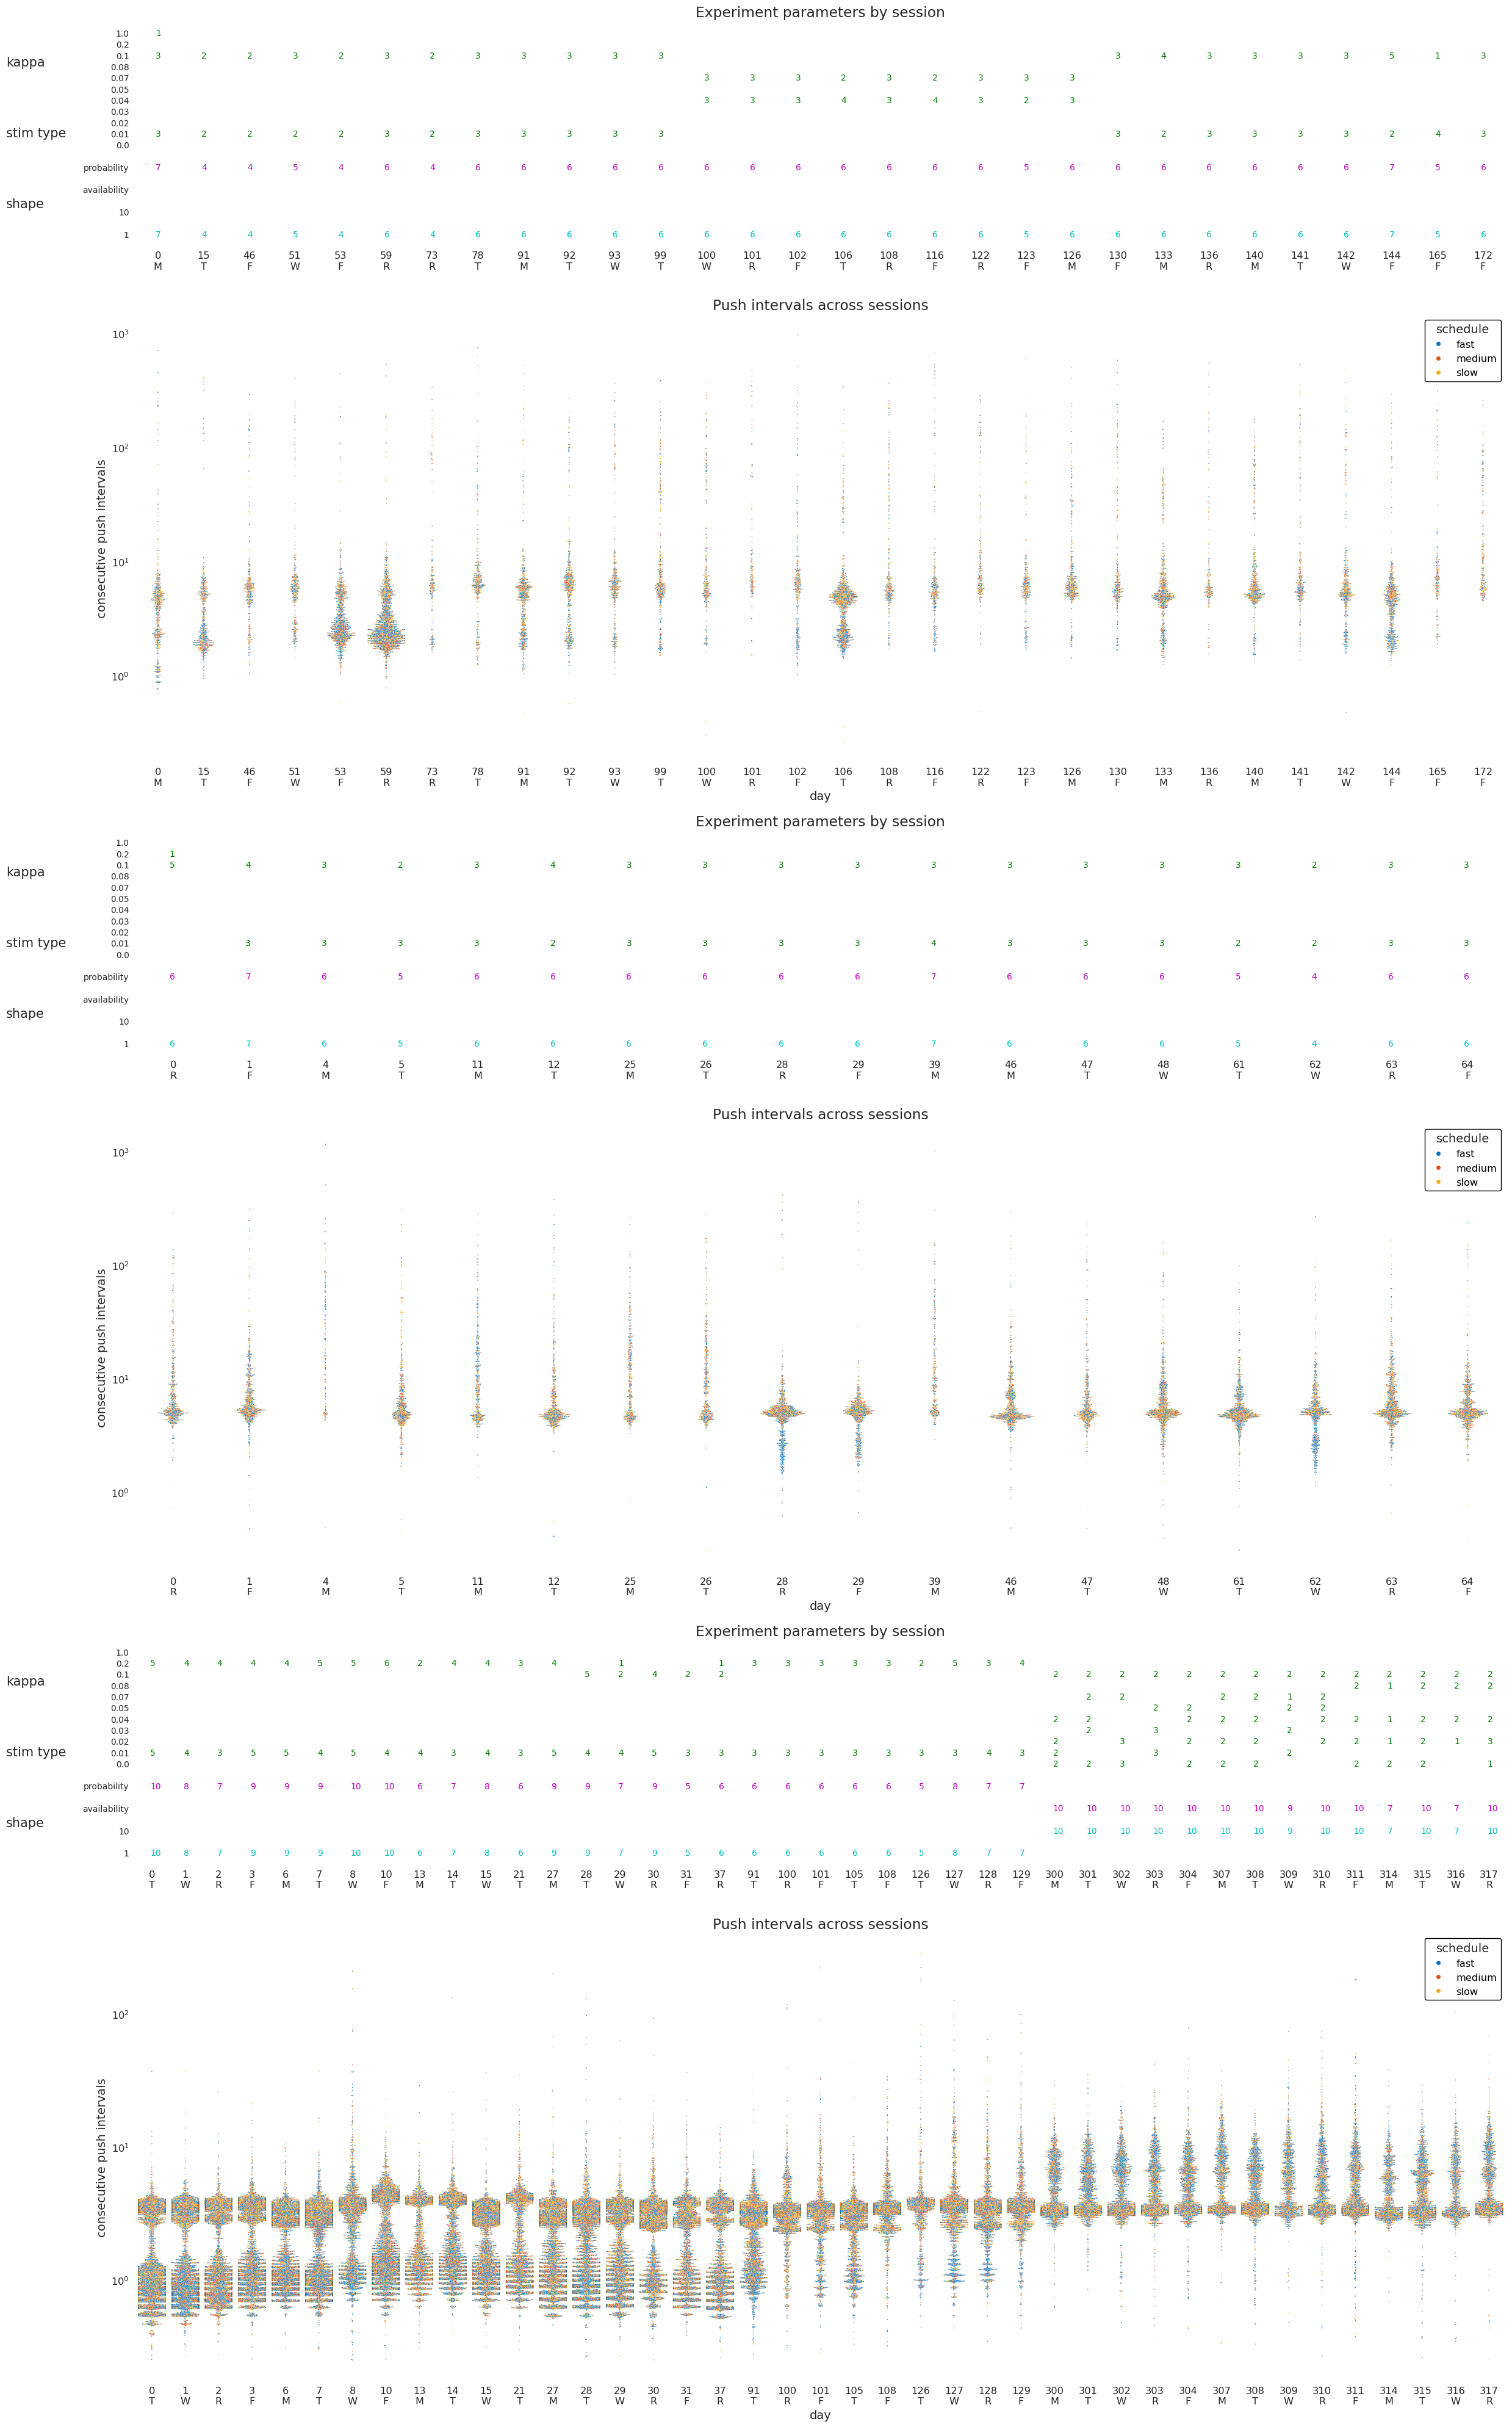

In [13]:
%%capture --no-display
# Reformat time data
df_monkey['session id'] = pd.to_datetime(df_monkey.index.get_level_values('session'), format='%Y%m%d')
df_ref = df_monkey.groupby('subject')['session id'].min()
df_monkey = df_monkey.join(df_ref, how='left', rsuffix='_ref', on=['subject'])
df_monkey['day'] = (df_monkey['session id'] - df_monkey['session id_ref']).dt.days

# Plot session data for each subject
fig, axes = plt.subplots(len(subjects) * 2, 1, figsize=(25, 40), height_ratios=[1, 2] * len(subjects))
for i, subject in enumerate(subjects):
    plot_experiment_parameters(df_monkey, conds={'subject': subject}, ax=axes[2 * i],
                               label_rotation=0)
    bp(sns.swarmplot)(df_monkey, x="day", y="consecutive push intervals", accumulate=True, conds={'subject': subject},
                      title_prefix="Push intervals across sessions", size=1, log_scale=True,
                      legend_kwargs={'markerscale': 5, 'loc': 'upper right'}, ax=axes[2 * i + 1])

    # Add weekday labels
    labels = axes[2 * i + 1].get_xticklabels()
    days = df_monkey.xs(subject, level='subject').reset_index().groupby(['session'], as_index=False)['week day'].max()[
        'week day']
    for j, l in enumerate(labels):
        tmp = l.get_text()
        labels[j] = tmp + '\n' + days[j]
    axes[2 * i + 1].set_xticklabels(labels)

    # Align x-axis
    axes[2 * i].sharex(axes[2 * i + 1])
fig.tight_layout()

These swarm plots are useful for visualizing individual data points by jittering the ones that collide, to the limit that the data points aren't too cluttered and impede comprehension. The x-axis denotes days since the first session (with day 0 corresponding to the first session) and the y-axis are the log push intervals in each session. For Dylan and Marco, the number of data points is manageable but for Viktor they are so numerous that you can see where the plot struggles to fit all the data points. Each swarm plot is preceded by an experiment overview where for each session we denote how many blocks had a certain experiment parameter, which gives us a sense of the timeline for how the experiment evolved and when decisions were made to change the experiment. The x-axes for a swarm plot and its corresponding experiment overview are aligned for ease of comparison.

This figure lets us see how many pushes occur in each session as well as how those pushes are distributed compared to the entire dataset for a given subject. One thing to look for are sessions that look distributionally different from the others, e.g. day 0 for Dylan shows a bump around extremely fast push intervals around 1 second, and days 53-59 contain a big bump of pushes right above 1 second. For Marco, day 4 is extremely scarce in pushes compared to other days.

It's interesting to see heterogeneous patterns in the pushes, in particular for Viktor. In fact, we see three distinct patterns of clusters organized in time: days 0-91 exhibit strong bimodality, days 100-129 are more unimodal and concentrate towards larger push intervals, and days 300-317 concentrate on even larger push intervals. Notice that day 300 coincides with a change in the experiment from the exponential schedule to gamma schedule.

## Space
### 3D Position

Below is an example block containing long periods of time where Marco does not push at a box and his corresponding 3D position in the arena over time. As you can see, the block contains a couple push intervals ie. between 400-600 seconds in the trial that take as long as a few hundred seconds, which translates to minutes not engaging with the task.

<Axes: title={'center': 'Push intervals\nsubject = marco, session = 20211221, block = 6'}, xlabel='push times (s)', ylabel='consecutive push intervals (s)'>

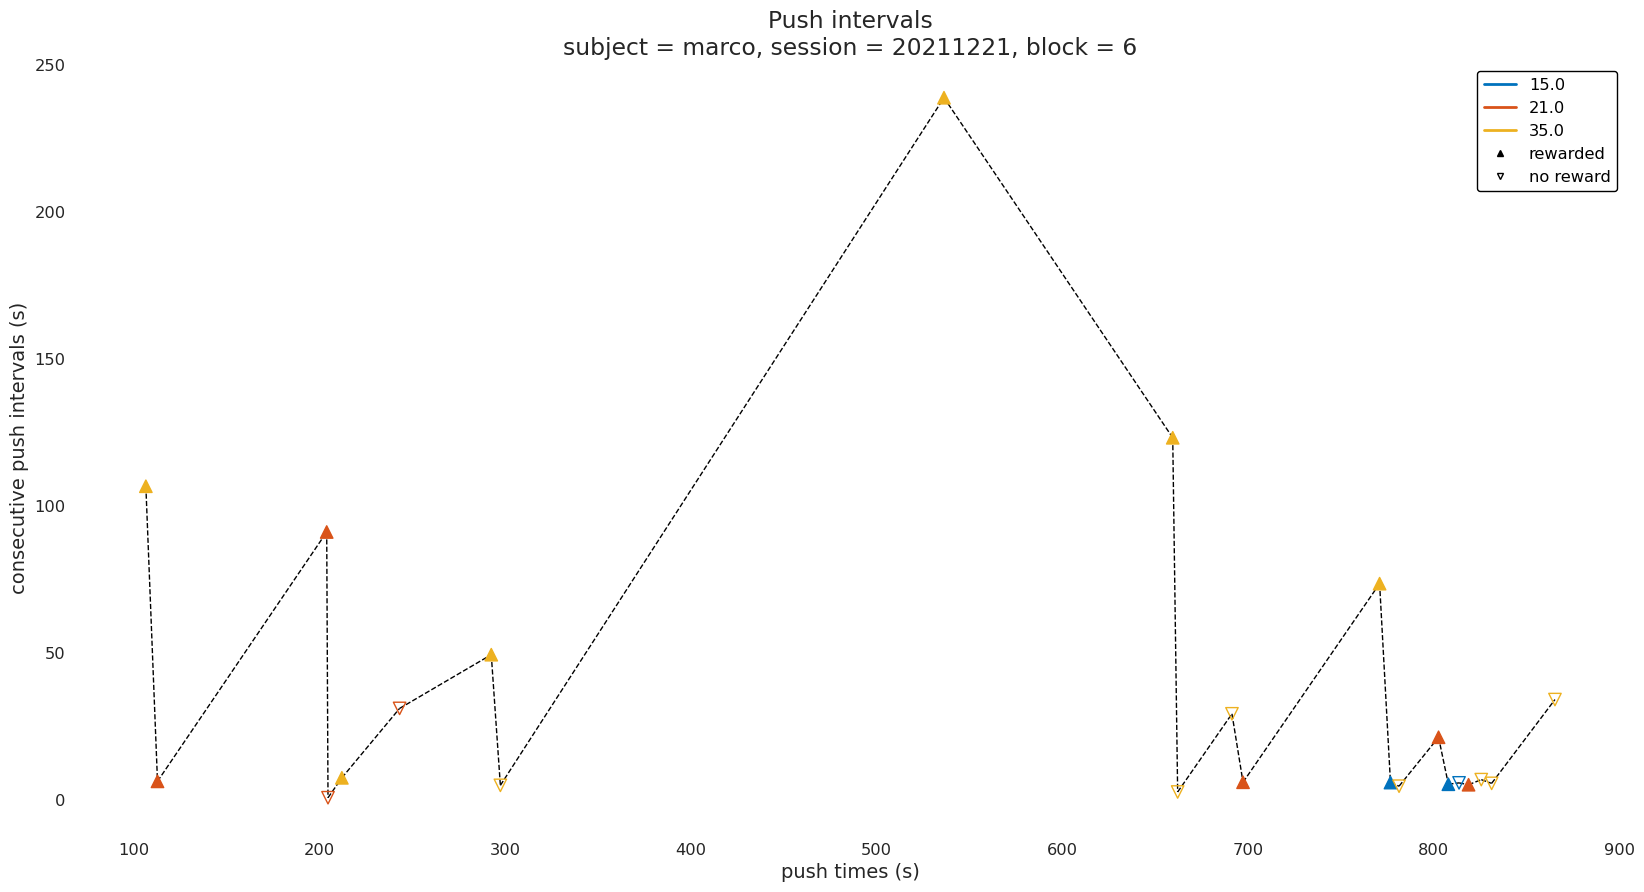

In [19]:
conds = {'subject': 'marco', 'session': 20211221, 'block': 6}
plot_block_events(df, conds=conds, y='consecutive push intervals', y_unit='s',
                  title=titler(title_prefix='Push intervals', conds=conds), legend=True)

The 3D plot of the position trajectory encodes time as color, and by eye we can see that between 400-600 seconds the monkey moved around and climbed up in the arena for some time.

(<Axes3D: title={'center': '3D Position of monkey'}>,
 <mpl_toolkits.mplot3d.art3d.Path3DCollection at 0x7f7dff4719f0>)

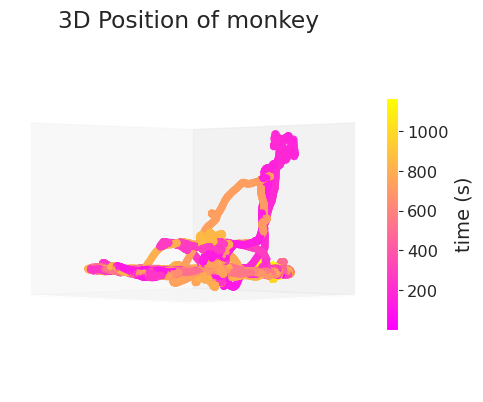

In [17]:
continuous_data, errors = get_continuous_from_df_to_dict(df_monkey, EXPERIMENT_DIR)
plot_continuous3d_dict(continuous_data, [tuple(conds.values())], x='position', title="3D Position of monkey",
                       plt_kwargs={'cmap': 'spring'},
                       cbar_kwargs={'shrink': 0.7, 'fraction': 0.03, 'label': 'time (s)'},
                       fig_kwargs={'figsize': (5, 5)})

Now we aggregate position data over multiple blocks below. First, we evenly sample pushes from all percentiles in a subject's data to ensure a fair representation of the positions occupied during these pushes. Then we plot the 3D coordinates of the positions occupied during these sampled push intervals and color them by the time that's passed since the last push.

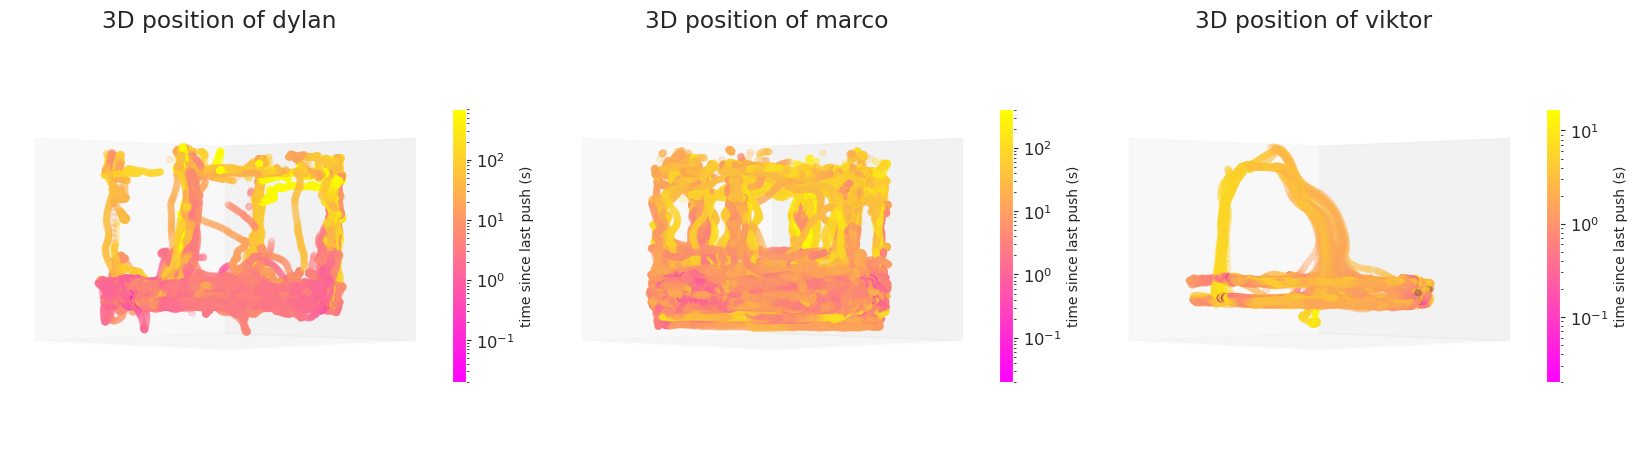

In [27]:
def filter_percentiles(df, p, n):
    subset = df.loc[(df['push percentiles'] >= p[0]) & (df['push percentiles'] <= p[1])]
    n = min(n, len(subset))  # Prevent errors if n > len(df)
    return subset.sample(n)


# Evenly sample pushes from each percentile bracket
n_samples = 1000
percentiles = zip(np.arange(0, 1, 0.2), np.arange(0.2, 1.2, 0.2))  # [(0, 0.2)...(0.8, 1)]
perc_dfs = []
for p in percentiles:
    perc_dfs.append(df_sorted.groupby('subject', group_keys=False).apply(filter_percentiles, p=p, n=n_samples))
all_perc_df = pd.concat(perc_dfs)  # This creates a DataFrame that groups pushes by subject and percentile brackets

# Plot each push's 3d position data as a function of time since the start of the push
fig = plt.figure(figsize=(20, 10))
cbars = []
for i, subject in enumerate(subjects):
    df_subj = filter_df(all_perc_df, {'subject': subject}, attempt_index=False)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    _, p = plot_continuous3d_df(df_subj, continuous_data, 'position', title=f'3D position of {subject}',
                                plt_kwargs={'alpha': 0.2, 'cmap': 'spring', 'norm': LogNorm()},
                                cbar_kwargs={'shrink': 0.7, 'fraction': 0.03, 'alpha': 1}, ax=ax)
    p.colorbar.set_label(p.colorbar.ax.get_ylabel(), fontsize=10)
    cbars.append(p.colorbar)

Across all subjects, there is a clear correlation between the vertical position occupied by the subject and the length of the push interval-- longer push intervals are associated with climbing around the arena more. To see this more clearly, we replot the data separating the pushes below the knees for each subject from the pushes above them.

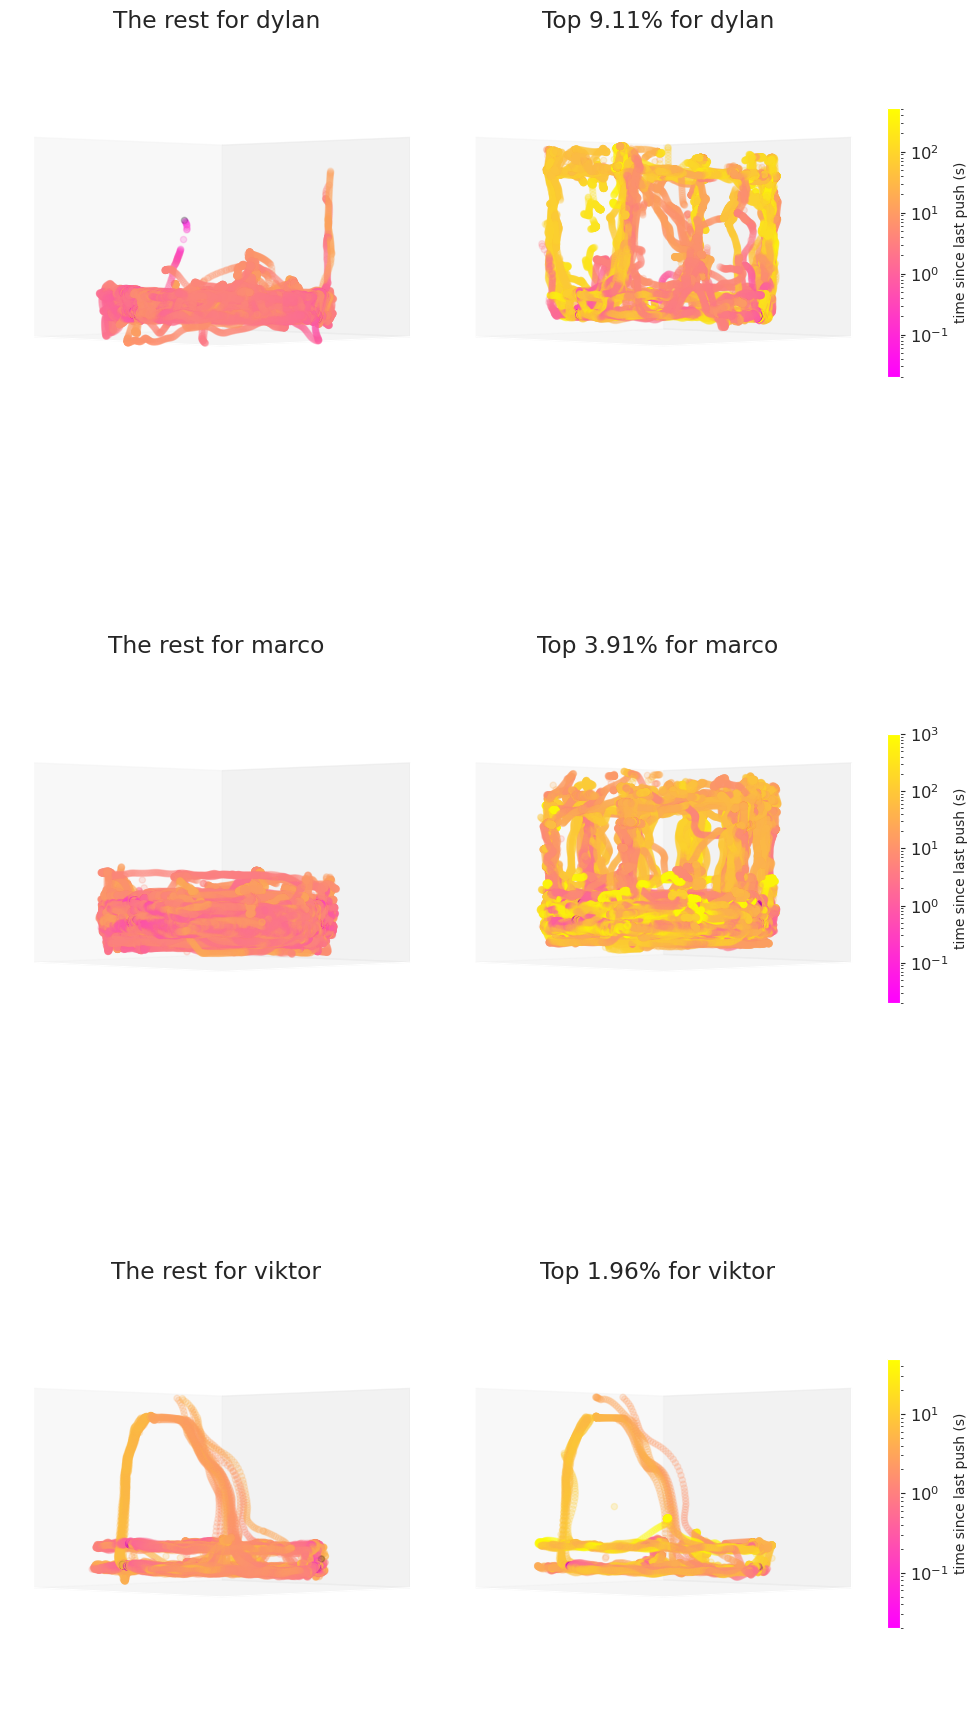

In [251]:
fig = plt.figure(figsize=(10, 20))
for i, subject in enumerate(subjects):
    df_subj = filter_df(all_perc_df, {'subject': subject}, attempt_index=False)
    perc = knees[subject]['perc']

    # The rest
    ax = fig.add_subplot(3, 2, 2 * i + 1, projection='3d')
    ax1, p1 = plot_continuous3d_df(df_subj[df_subj['push percentiles'] < perc], continuous_data,
                                   'position', title=f'The rest for {subject}',
                                   plt_kwargs={'alpha': 0.2, 'cmap': 'spring', 'norm': LogNorm()},
                                   cbar_kwargs={'shrink': 0.7, 'fraction': 0.03, 'alpha': 1}, ax=ax)
    c1 = p1.colorbar

    # Top x%
    ax = fig.add_subplot(3, 2, 2 * i + 2, projection='3d', sharex=ax, sharey=ax, sharez=ax)
    ax2, p2 = plot_continuous3d_df(df_subj[df_subj['push percentiles'] >= perc], continuous_data,
                                   'position', title=f'Top {(1 - perc) * 100:.2f}% for {subject}',
                                   plt_kwargs={'alpha': 0.2, 'cmap': 'spring', 'norm': LogNorm()},
                                   cbar_kwargs={'shrink': 0.7, 'fraction': 0.03, 'alpha': 1}, ax=ax)
    c2 = p2.colorbar
    c2.set_label(c2.ax.get_ylabel(), fontsize=10)

    # Modify colors to be on the same scale post-hoc
    vmin = cbars[i].norm.vmin
    vmax = cbars[i].norm.vmax
    p1.set_clim(vmin, vmax)
    p2.set_clim(vmin, vmax)

    # Do this to preserve spatial layout
    c1.ax.set_visible(False)
fig.tight_layout()

Now that they are separated, we can clearly see for Dylan and Marco, that whenever the monkey spends time climbing, these are associated with the monkey taking the most time between pushes. Notably, Viktor engages in this behavior the least, displaying one vertical arc shared between pushes below and above his knee. What is unclear is whether these trajectories reflect a monkey in motion on its way to a box, or a relaxed monkey not engaging with the task. To resolve this, one would need to consider the velocity at each position, which we leave for future work.

### 2D Position

We also consider the positions occupied while on the floor, which are defined as when the vertical z-coordinate falls below 500 mm, the height of the boxes.

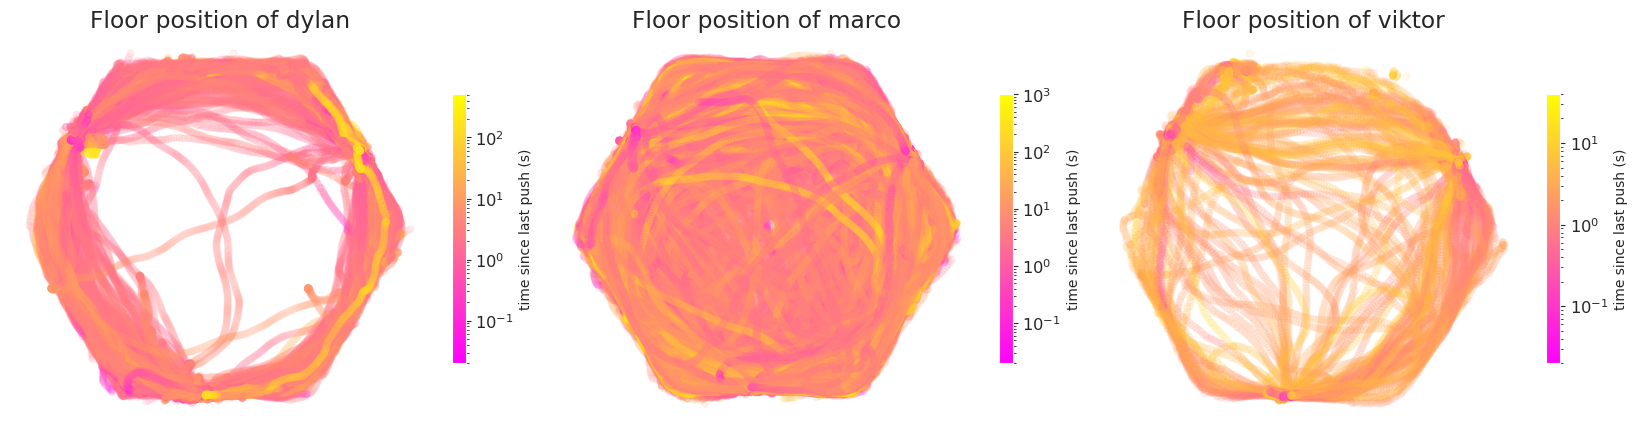

In [252]:
continuous_data_floor = {}
for k, v in continuous_data.items():
    idx = v['position'][:, 2] < 500
    continuous_data_floor[k] = {}
    for k1, v1 in v.items():
        if isinstance(v1, dict):
            continuous_data_floor[k][k1] = {k2: v2[idx] for k2, v2 in v1.items()}
        else:
            continuous_data_floor[k][k1] = v1[idx]

# Plot each push's 2d position data as a function of time since the start of the push
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
for i, subject in enumerate(subjects):
    df_subj = filter_df(all_perc_df, {'subject': subject}, attempt_index=False)
    _, p = plot_continuous2d_df(df_subj, continuous_data_floor, 'position',
                                title=f'Floor position of {subject}',
                                plt_kwargs={'alpha': 0.1, 'cmap': 'spring', 'norm': LogNorm()},
                                cbar_kwargs={'shrink': 0.7, 'fraction': 0.03, 'alpha': 1}, ax=ax[i])
    p.colorbar.set_label(p.colorbar.ax.get_ylabel(), fontsize=10)

Dylan seems to avoid the center, keeping to the edge of the arena while Marco moves all over the place. Viktor seems to avoid some of the center to a lesser extent.

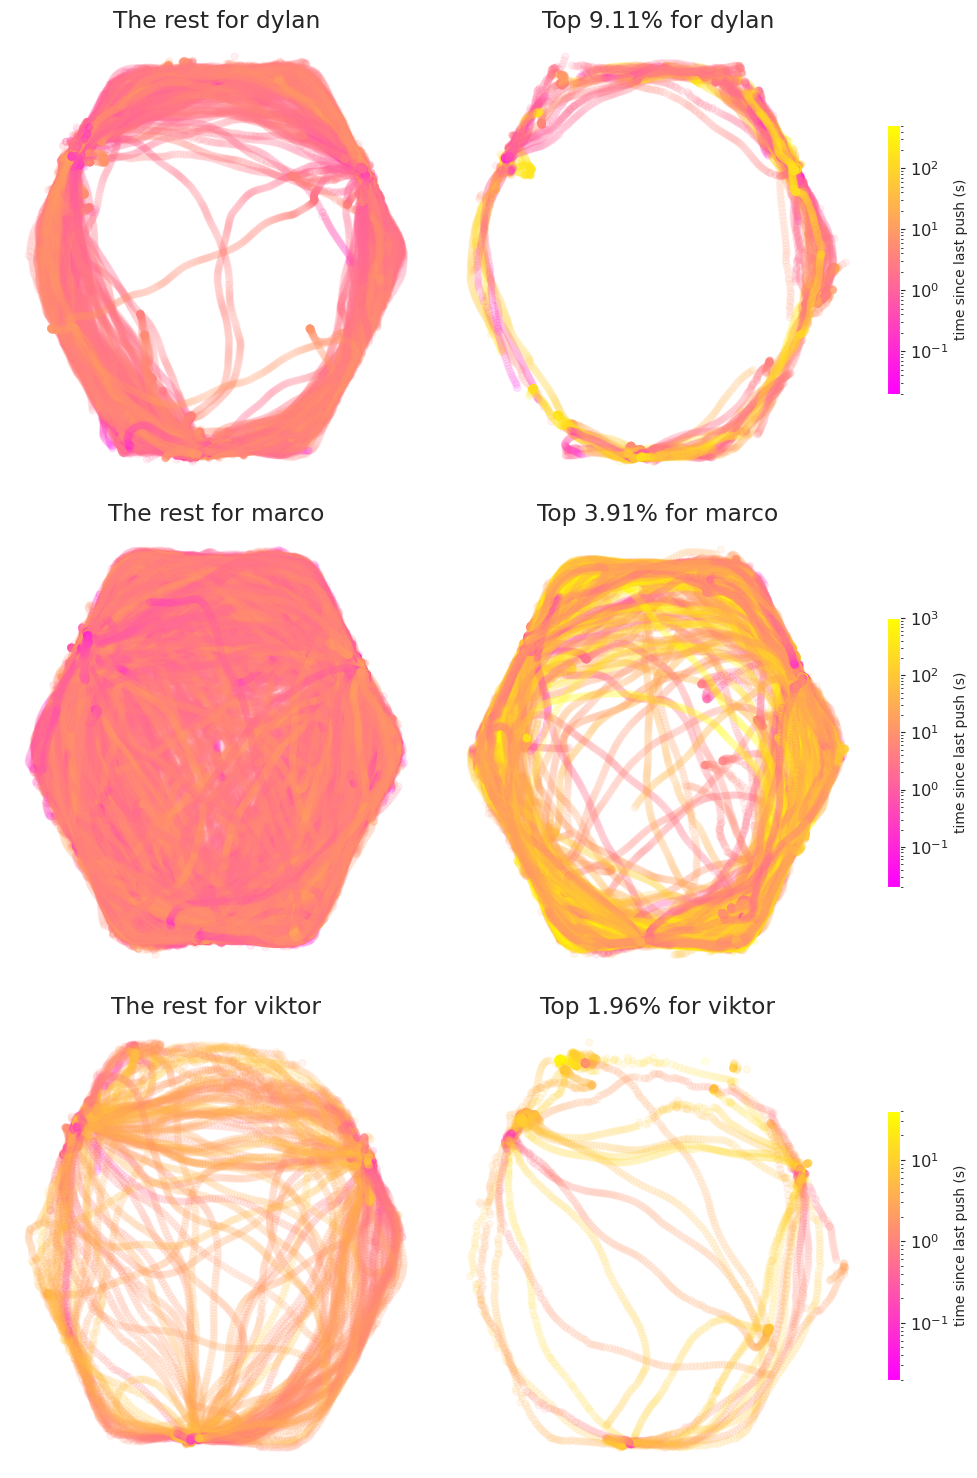

In [254]:
fig, ax = plt.subplots(3, 2, figsize=(10, 15))
for i, subject in enumerate(subjects):
    df_subj = filter_df(all_perc_df, {'subject': subject}, attempt_index=False)
    perc = knees[subject]['perc']

    # The rest
    ax1, p1 = plot_continuous2d_df(df_subj[df_subj['push percentiles'] < perc], continuous_data_floor,
                                   'position', title=f'The rest for {subject}',
                                   plt_kwargs={'alpha': 0.1, 'cmap': 'spring', 'norm': LogNorm()},
                                   cbar_kwargs={'shrink': 0.7, 'fraction': 0.03, 'alpha': 1},
                                   ax=ax[i][0])
    c1 = p1.colorbar
    c1.set_label(c1.ax.get_ylabel(), fontsize=10)

    # top x%
    ax2, p2 = plot_continuous2d_df(df_subj[df_subj['push percentiles'] >= perc],
                                   continuous_data_floor,
                                   'position', title=f'Top {(1 - perc) * 100:.2f}% for {subject}',
                                   plt_kwargs={'alpha': 0.1, 'cmap': 'spring', 'norm': LogNorm()},
                                   cbar_kwargs={'shrink': 0.7, 'fraction': 0.03, 'alpha': 1},
                                   ax=ax[i][1])
    c2 = p2.colorbar
    c2.set_label(c2.ax.get_ylabel(), fontsize=10)

    # Modify colors to be on the same scale post-hoc
    vmin = c2.norm.vmin
    vmax = c2.norm.vmax
    p1.set_clim(vmin, vmax)

    # Do this to preserve spatial layout
    c1.ax.set_visible(False)
fig.tight_layout()

It seems that when Dylan waits for a while before pushing, he sticks closer to the edge. Marco also does this to a lesser extent, but Viktor's positions don't differ much between the long push intervals and the rest.

## HMM Policy Identification
Dr. Zhe Li has been developing an automatic, data-driven way to identify patterns and clusters in the behavioral data. Fitting an HMM over a diverse set of policies, he has shared the probabilities of 2 policies over time in several blocks of Marco's behavior. Here, we overlay them on top of push intervals in a given block and observe what the HMM is picking out.

Text(0, 0.5, 'HMM Policy Probability')

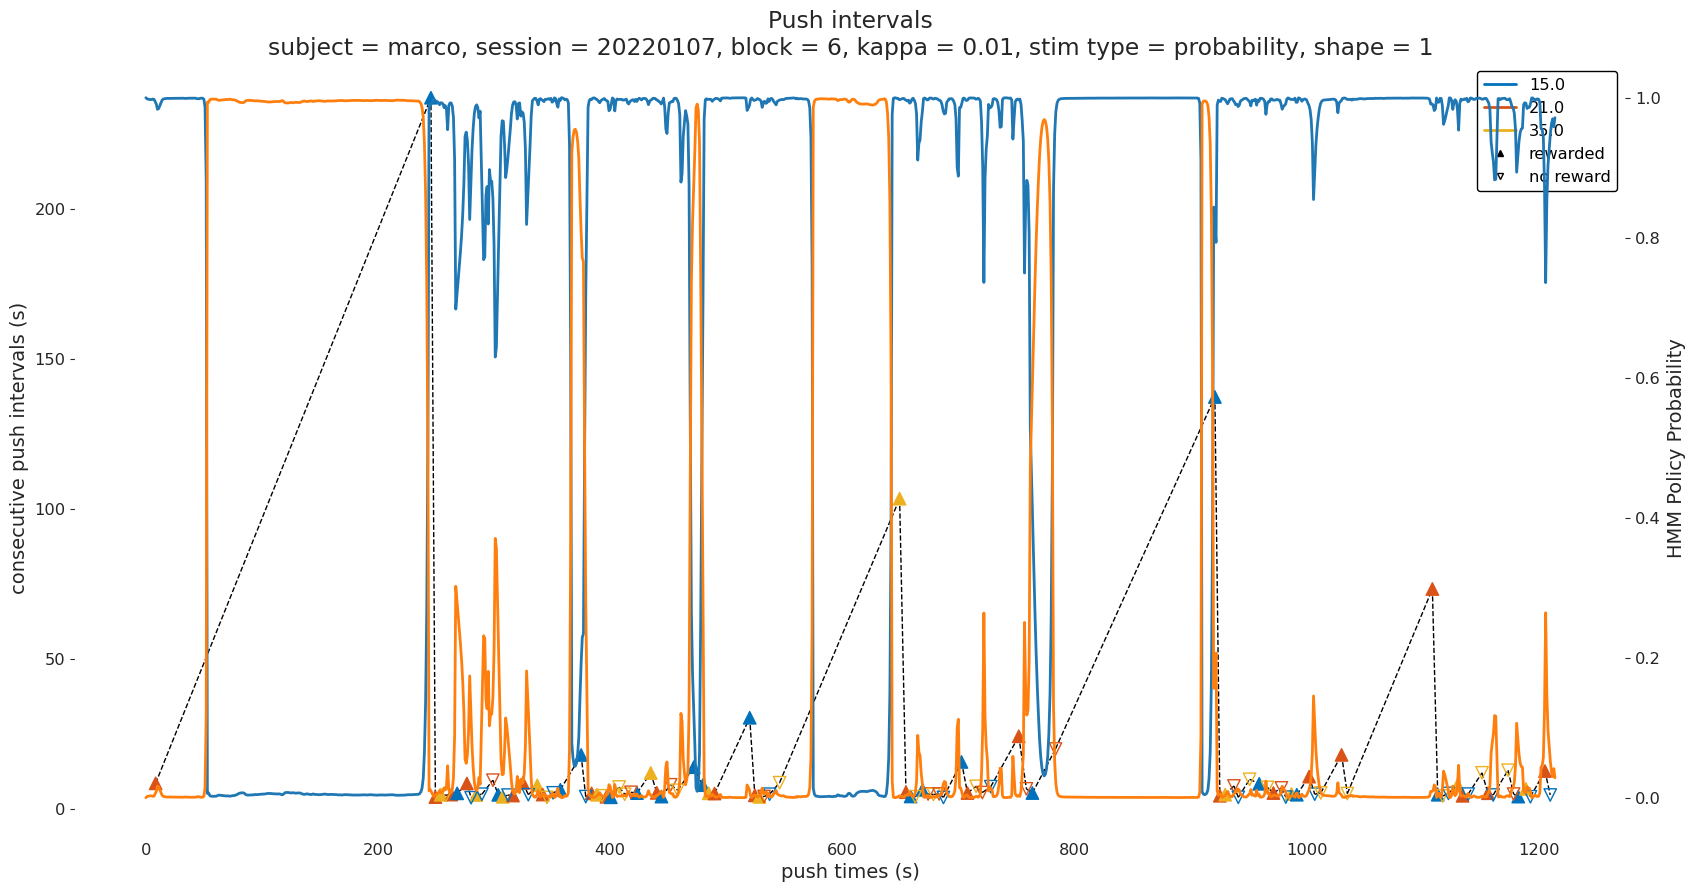

In [20]:
# Load HMM probabilities
with open(os.path.join(ANALYSIS_DIR, 'HMM.solution_[K2].pkl'), 'rb') as f:
    saved = pickle.load(f)

subject, kappa, block_ids = saved['subject'], saved['kappa'], saved['block_ids']
pos, gaze = saved['pos'], saved['gaze']
push, move, look = saved['push'], saved['move'], saved['look']
p_policy = saved['p_policy']

# Overlay probabilities on top of a specific block
block_idx = 30
session_id, block = block_ids[block_idx]
hmm_probs = p_policy[block_idx]
ax = plot_block_events(df, conds=dict(subject=subject, session=int(session_id), block=block + 1),
                       y='consecutive push intervals', y_unit='s', title_prefix='Push intervals')
ax2 = ax.twinx()
ax2.plot(hmm_probs)
ax2.set_ylabel('HMM Policy Probability')

In [192]:
# Save figure
fig = ax2.get_figure()
fig_path = os.path.join(FIGURES_DIR, f'subject {subject}')
os.makedirs(fig_path, exist_ok=True)
conds = {'subject': subject, 'session': session_id, 'block': block + 1}
fig.savefig(os.path.join(fig_path, 'hmm_' + ','.join([k + '=' + str(v) for k, v in conds.items()]) + '.png'))

# Clean Data

Taking all these observations into account, the following is a preliminary exclusion criteria:

+ remove all blocks with less than 10 pushes
+ remove all blocks where the schedules contain 80 s as one of the boxes
+ remove pushes greater than 30 s where the monkey is not pushing anything

This can be greatly expanded upon and refined through various data wrangling schemes, such as dimensionality reduction via PCA or t-SNE, and automated methods that we are currently developing. For now, this is a baseline criteria that serves as a starting point for more advanced analysis.

In [260]:
df_filtered = exclusion_criteria(df)
print(f'Applying exclusion criteria dropped {len(df) - len(df_filtered)} pushes')

Applying exclusion criteria dropped 3022 pushes


<Axes: title={'center': "Distribution of push intervals\nsubject = ['dylan', 'marco', 'viktor']"}, xlabel='subject', ylabel='consecutive push intervals (s)'>

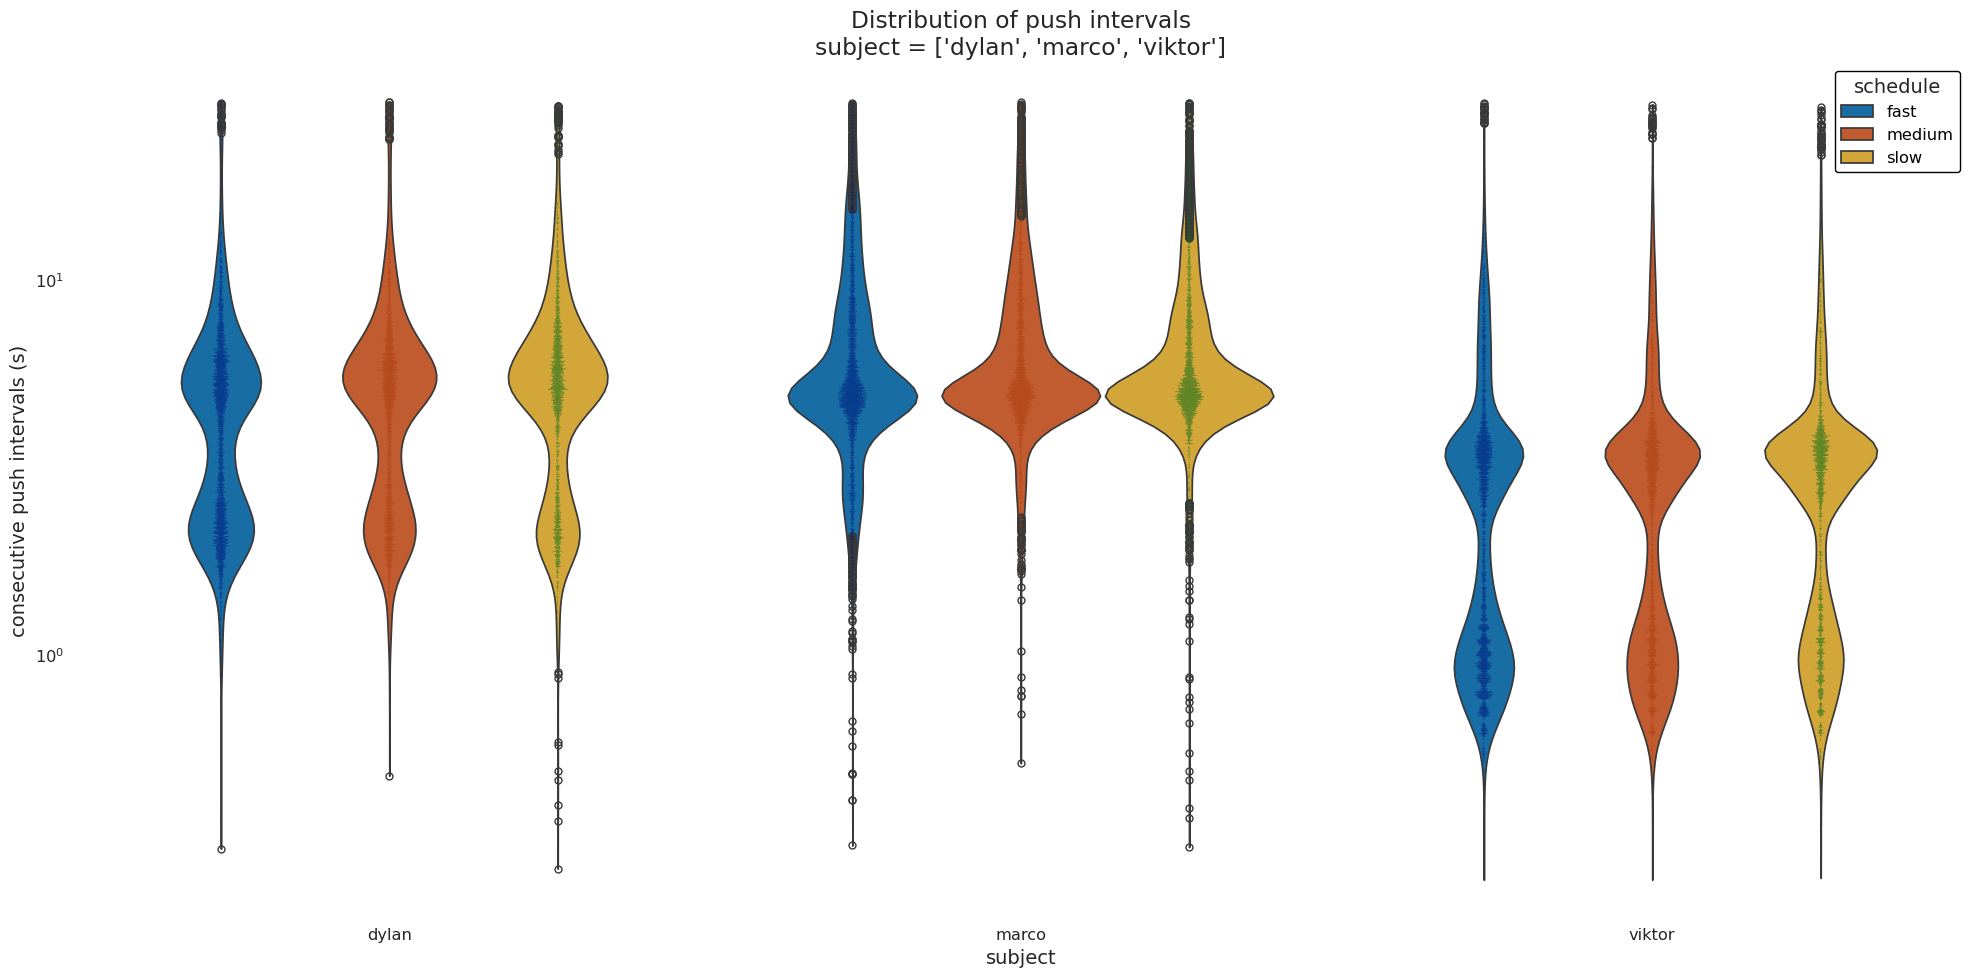

In [262]:
# Examine monkeys separately from humans
conds = {'subject': ['dylan', 'marco', 'viktor']}
df_monkey = filter_df(df_filtered, conds).copy()

# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
bp(sns.boxplot)(df_monkey, conds=conds, x='subject', y='consecutive push intervals', accumulate=True, showcaps=False,
                showbox=False, log_scale=True, whiskerprops={'visible': False}, medianprops={'visible': False},
                legend=False, ax=ax)
bp(sns.swarmplot)(df_monkey.groupby('subject').sample(10000, random_state=SEED), conds=conds, x='subject',
                  y='consecutive push intervals', accumulate=True, legend=False, log_scale=True, size=0.5, dodge=True,
                  palette='dark', ax=ax)
bp(sns.violinplot)(df_monkey, conds=conds, x='subject', y='consecutive push intervals', accumulate=True, cut=0,
                   inner=None, log_scale=True, common_norm=True, title_prefix="Distribution of push intervals",
                   y_unit='s', ax=ax)

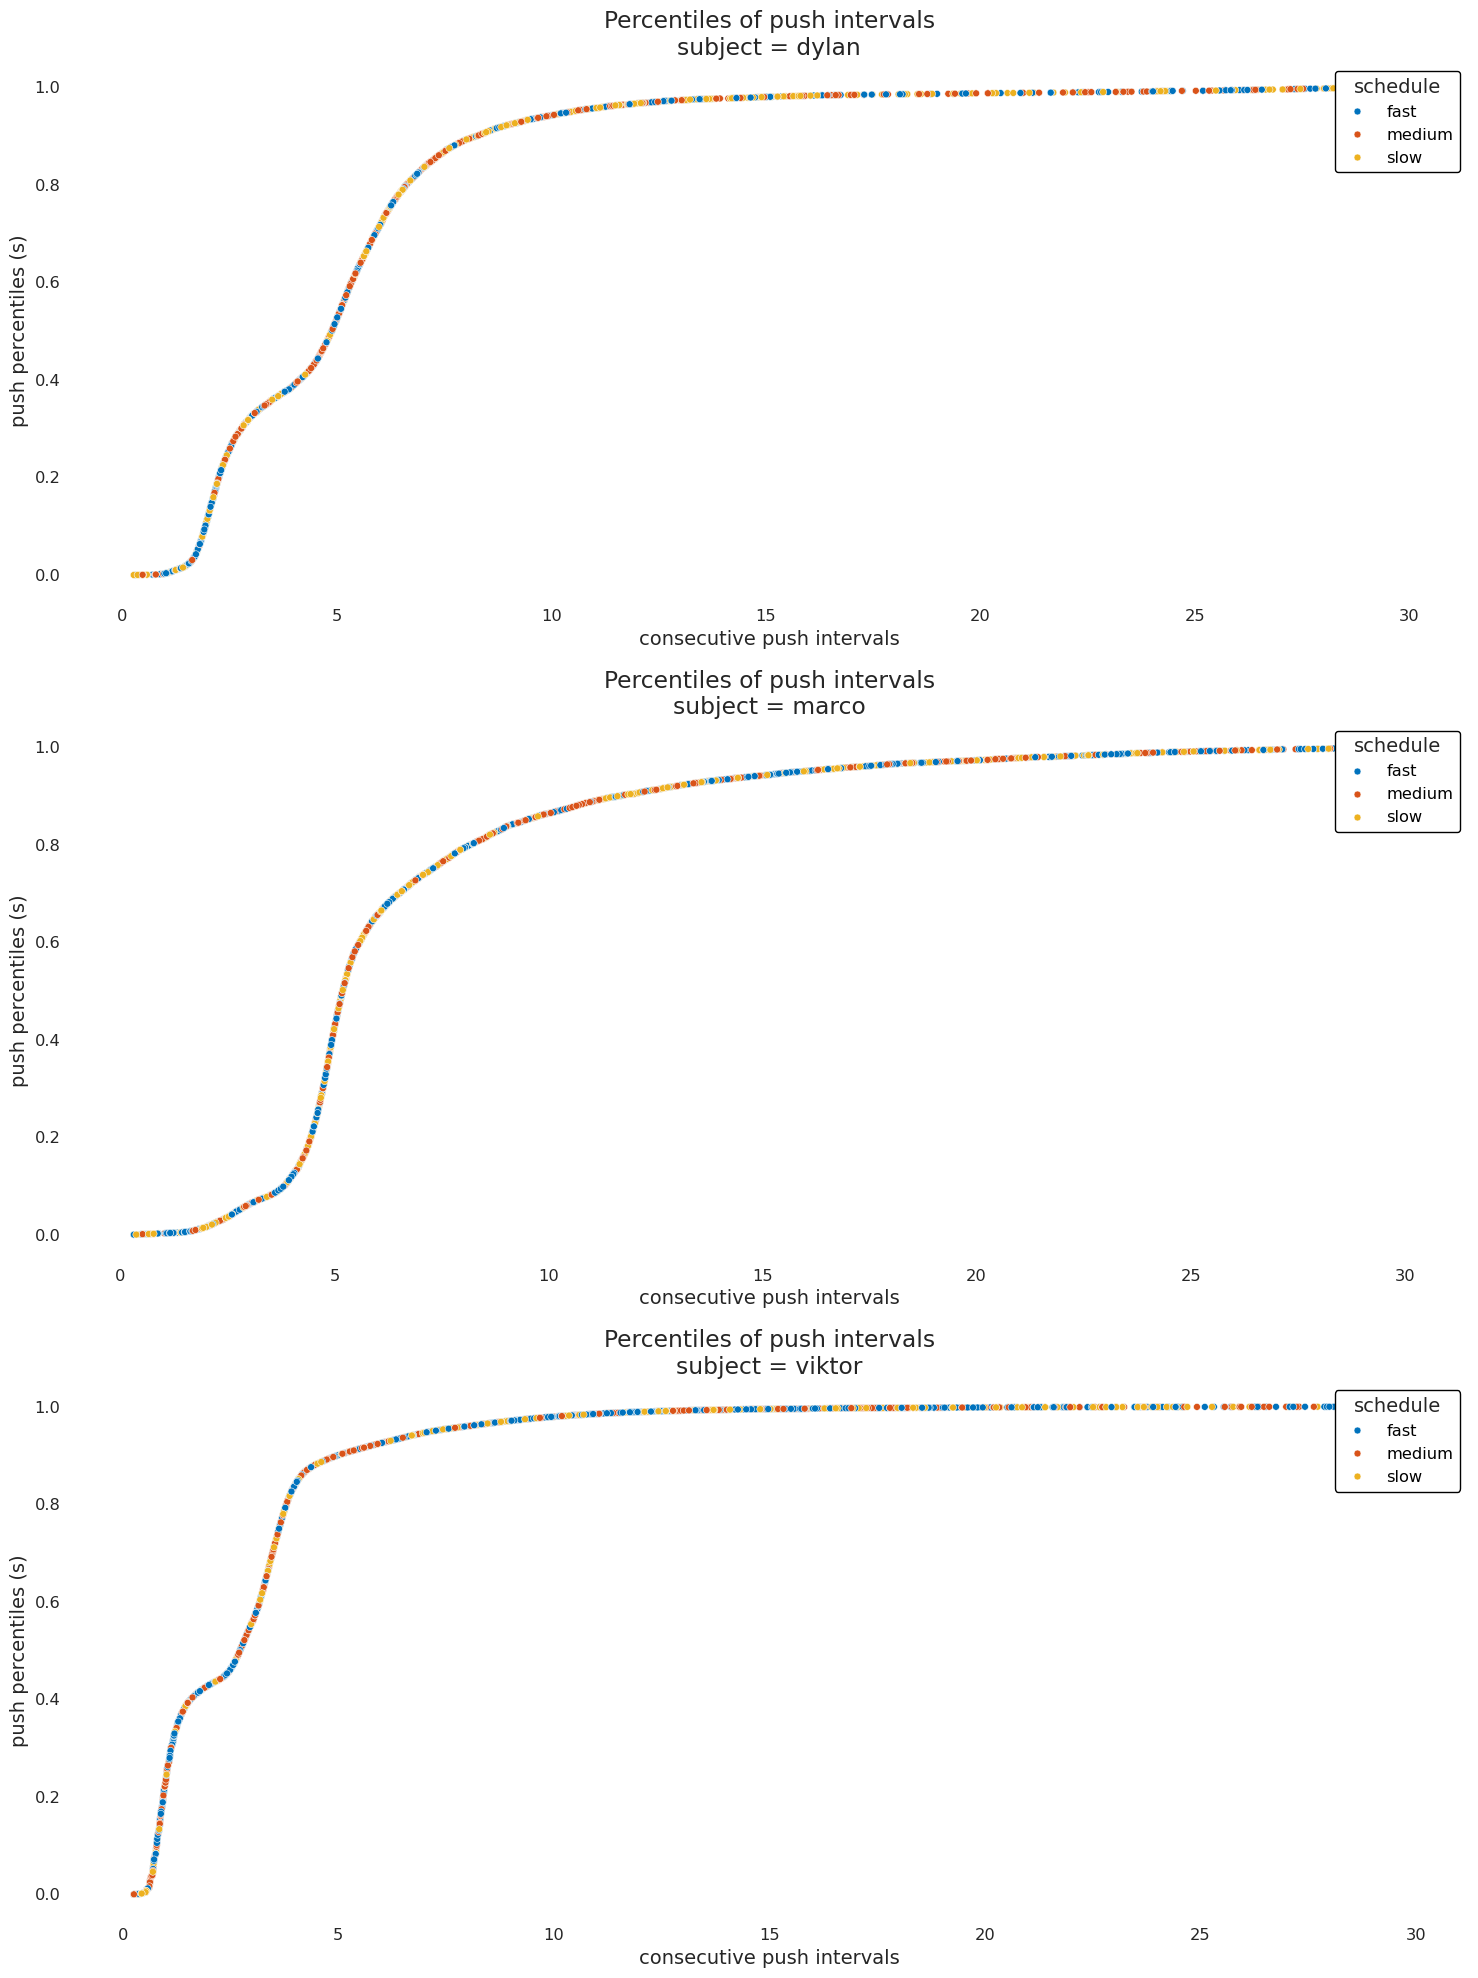

In [263]:
df_monkey['push percentiles'] = df_monkey.groupby('subject', as_index=False)['consecutive push intervals'].rank(
    pct=True)
subjects = df_monkey.index.unique('subject')
fig, axes = plt.subplots(len(subjects), 1, figsize=(15, 20))
for i, subj in enumerate(subjects):
    bp(sns.scatterplot)(df_monkey, x='consecutive push intervals', y='push percentiles', accumulate=True,
                        conds={'subject': subj}, title_prefix="Percentiles of push intervals", y_unit='s', ax=axes[i])
fig.tight_layout()

Compare to the beginning of this notebook. After removing the outliers for each subject, we see now that the push intervals are within a more reasonable range and cluster closer together.